# Phase 2 - Model Training
## Secure AI-Based Handwritten Text Recognition for Indian Scripts

### Abstract alignment:
- Deep Learning model (CNN + BiLSTM + CTC) for recognizing handwritten characters in Indian scripts
- Trained on preprocessed, augmented Hindi + Telugu datasets from Phase 1
- Forms the base intelligent recognition engine - later secured via Federated Learning (Phase 3) and Blockchain (Phase 4)

### Architecture:
- CNN - extracts visual stroke/shape features from each character image
- BiLSTM - models sequential dependencies in both directions across the feature map
- CTC Loss - enables alignment-free training

### Languages: Hindi, Telugu
### Resumable: epoch-level checkpoints - safe against Colab runtime disconnects
### RAM-safe: images are loaded lazily, one batch at a time - never all at once
### Reads from: OCR_Project/processed/{train,val,test}/ (created in Phase 1)

---
## Cell 1 - Install Dependencies

In [67]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q matplotlib scikit-learn tqdm Pillow opencv-python-headless
print('Dependencies installed!')

Dependencies installed!


---
## Cell 2 - Imports

In [68]:
import os
import gc
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU   : {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('   No GPU - go to Runtime > Change runtime type > T4 GPU')

Using device: cpu
   No GPU - go to Runtime > Change runtime type > T4 GPU


---
## Cell 3 - Drive Mount + Paths (standard block - same across all phases)

In [69]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR  = Path('/content/drive/MyDrive/OCR_Project')
RAW_DIR   = BASE_DIR / 'raw'
DATA_DIR  = BASE_DIR / 'processed'
MODEL_DIR = BASE_DIR / 'models'
LOG_DIR   = BASE_DIR / 'logs'
OUT_DIR   = BASE_DIR / 'outputs'

TRAIN_DIR      = DATA_DIR  / 'train'
VAL_DIR        = DATA_DIR  / 'val'
TEST_DIR       = DATA_DIR  / 'test'
CHECKPOINT_DIR = MODEL_DIR / 'checkpoints'
FINAL_DIR      = MODEL_DIR / 'final'

for d in [CHECKPOINT_DIR, FINAL_DIR, LOG_DIR,
          OUT_DIR/'predictions', OUT_DIR/'evaluation']:
    d.mkdir(parents=True, exist_ok=True)

print('Drive mounted!')
print(f'   Data   : {DATA_DIR}')
print(f'   Models : {MODEL_DIR}')
print(f'   Outputs: {OUT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted!
   Data   : /content/drive/MyDrive/OCR_Project/processed
   Models : /content/drive/MyDrive/OCR_Project/models
   Outputs: /content/drive/MyDrive/OCR_Project/outputs


---
## Cell 4 - Label Encoder (Class Map from Phase 1 output)

In [70]:
def build_label_map(train_dir):
    labels = set()
    for lang_folder in Path(train_dir).iterdir():
        if lang_folder.is_dir():
            for label_folder in lang_folder.iterdir():
                if label_folder.is_dir():
                    labels.add(label_folder.name)
    labels = sorted(labels)
    label2idx = {l: i for i, l in enumerate(labels)}
    idx2label = {i: l for l, i in label2idx.items()}
    return label2idx, idx2label

label_map_path = MODEL_DIR / 'label_map.json'

if label_map_path.exists():
    print('Label map already exists - loading (will not rescan folders)')
    with open(label_map_path) as f:
        saved = json.load(f)
    label2idx   = saved['label2idx']
    idx2label   = {int(k): v for k, v in saved['idx2label'].items()}
    NUM_CLASSES = saved['num_classes']
else:
    label2idx, idx2label = build_label_map(TRAIN_DIR)
    NUM_CLASSES = len(label2idx)
    with open(label_map_path, 'w') as f:
        json.dump({'label2idx': label2idx,
                   'idx2label': idx2label,
                   'num_classes': NUM_CLASSES}, f,
                  ensure_ascii=False, indent=2)
    print('Label map built fresh and saved!')

print(f'   Total classes : {NUM_CLASSES}')
print(f'   Sample labels : {list(label2idx.items())[:8]}')

Label map already exists - loading (will not rescan folders)
   Total classes : 427
   Sample labels : [('Hindi_character_10_yna', 0), ('Hindi_character_11_taamatar', 1), ('Hindi_character_12_thaa', 2), ('Hindi_character_13_daa', 3), ('Hindi_character_14_dhaa', 4), ('Hindi_character_15_adna', 5), ('Hindi_character_16_tabala', 6), ('Hindi_character_17_tha', 7)]


In [71]:
#verify all backups

!ls -lh /content/drive/MyDrive/OCR_Project/*.tar

-rw------- 1 root root 142M Jun 24 04:42 /content/drive/MyDrive/OCR_Project/test_hindi.tar
-rw------- 1 root root 359M Jun 24 05:10 /content/drive/MyDrive/OCR_Project/test_telugu.tar
-rw------- 1 root root 636M Jun 24 02:41 /content/drive/MyDrive/OCR_Project/train_hindi.tar
-rw------- 1 root root 1.6G Jun 24 05:59 /content/drive/MyDrive/OCR_Project/train_telugu.tar
-rw------- 1 root root 136M Jun 24 03:04 /content/drive/MyDrive/OCR_Project/val_hindi.tar
-rw------- 1 root root 344M Jun 24 03:36 /content/drive/MyDrive/OCR_Project/val_telugu.tar


In [72]:
# ============================================
# EXTRACT ALL TAR FILES TO LOCAL SSD
# ============================================

!rm -rf /content/processed_local

!mkdir -p /content/processed_local/train
!mkdir -p /content/processed_local/val
!mkdir -p /content/processed_local/test

# -------------------------
# TRAIN
# -------------------------

!tar -xf /content/drive/MyDrive/OCR_Project/train_hindi.tar \
-C /content/processed_local/train

!tar -xf /content/drive/MyDrive/OCR_Project/train_telugu.tar \
-C /content/processed_local/train

# -------------------------
# VAL
# -------------------------

!tar -xf /content/drive/MyDrive/OCR_Project/val_hindi.tar \
-C /content/processed_local/val

!tar -xf /content/drive/MyDrive/OCR_Project/val_telugu.tar \
-C /content/processed_local/val

# -------------------------
# TEST
# -------------------------

!tar -xf /content/drive/MyDrive/OCR_Project/test_hindi.tar \
-C /content/processed_local/test

!tar -xf /content/drive/MyDrive/OCR_Project/test_telugu.tar \
-C /content/processed_local/test

print("All TAR files extracted successfully!")

All TAR files extracted successfully!


In [73]:
# ============================================
# VERIFY LOCAL DATASET
# ============================================

!find /content/processed_local/train -type f | wc -l
!find /content/processed_local/val   -type f | wc -l
!find /content/processed_local/test  -type f | wc -l

709214
151708
151706


---
## Cell 5 - Dataset Class + DataLoaders (RAM-safe)

**RAM safety notes:**
- `__init__` only walks folders and stores (path, label, language) tuples - a few million short strings, not images. For ~1M samples this is roughly 150-250 MB of RAM, not gigabytes.
- `__getitem__` decodes exactly ONE image at a time, on demand, when the DataLoader asks for it. The image is discarded right after it's batched and sent to the model - nothing is cached in memory.
- `num_workers=2` is kept modest (not 4+) so each persistent worker subprocess (which duplicates this small samples list) doesn't add up to much extra RAM.
- `pin_memory` is only enabled when a GPU is actually present, since it has no benefit and only costs RAM on CPU-only runtimes.

In [74]:
# ============================================
# CELL 5 - Dataset Class (LOCAL SSD Optimized)
# Advanced: Augmentation + Normalization + Fast Loading
# ============================================
import random
import numpy as np
import cv2
import torch
import torchvision.transforms as T
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

LOCAL_DATA_DIR = Path('/content/processed_local')

# ── Augmentation pipeline (training only) ──────────────
# Light augmentation — handwriting characters ki aggressive transforms harm chestāyi
train_transforms = T.Compose([
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.2),
    T.RandomApply([T.RandomAffine(
        degrees=5,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=3
    )], p=0.4),
])

class OCRDataset(Dataset):

    def __init__(self, data_dir, label2idx, split,
                 img_h=64, img_w=128, augment=False):
        self.data_dir  = Path(data_dir) / split
        self.label2idx = label2idx
        self.img_h     = img_h
        self.img_w     = img_w
        self.augment   = augment
        self.samples   = []

        exts = {'.png', '.jpg', '.jpeg'}
        print(f'\nIndexing {split} dataset...')

        for lang_folder in sorted(self.data_dir.iterdir()):
            if not lang_folder.is_dir(): continue
            for label_folder in sorted(lang_folder.iterdir()):
                if not label_folder.is_dir(): continue
                label = label_folder.name
                if label not in label2idx: continue
                lang_name = lang_folder.name
                for img_path in label_folder.iterdir():
                    if img_path.suffix.lower() in exts:
                        self.samples.append(
                            (str(img_path), label2idx[label], lang_name))

        random.shuffle(self.samples)
        print(f'   {split:5} : {len(self.samples):,} samples '
              f'(augment={augment})')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, lang = self.samples[idx]

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.zeros((self.img_h, self.img_w), dtype=np.uint8)

        # Resize with INTER_AREA (best for downscaling)
        img = cv2.resize(img, (self.img_w, self.img_h),
                         interpolation=cv2.INTER_AREA)

        # Normalize to [0, 1]
        img = img.astype(np.float32) / 255.0

        # Convert to tensor (1, H, W)
        img_tensor = torch.from_numpy(img).unsqueeze(0)

        # Apply augmentation (training only)
        if self.augment:
            img_tensor = train_transforms(img_tensor)

        return img_tensor, label

    def get_language(self, idx):
        return self.samples[idx][2]


# ── CONFIG ─────────────────────────────────────────────
IMG_H          = 64
IMG_W          = 128
BATCH_SIZE     = 128      # 64→128: GPU better utilize avutundi T4 lo
NUM_WORKERS    = 2        # Colab segfault fix
USE_PIN_MEMORY = torch.cuda.is_available()

# ── LOAD DATASETS ──────────────────────────────────────
print('\nLoading datasets from LOCAL SSD...')

train_dataset = OCRDataset(LOCAL_DATA_DIR, label2idx, 'train',
                           IMG_H, IMG_W, augment=True)   # ← augmentation ON
val_dataset   = OCRDataset(LOCAL_DATA_DIR, label2idx, 'val',
                           IMG_H, IMG_W, augment=False)
test_dataset  = OCRDataset(LOCAL_DATA_DIR, label2idx, 'test',
                           IMG_H, IMG_W, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0,
                          pin_memory=USE_PIN_MEMORY)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0,
                          pin_memory=USE_PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0,
                          pin_memory=USE_PIN_MEMORY)

print('\nDataset Loading Complete!')
print(f'   Train : {len(train_dataset):,} (with augmentation)')
print(f'   Val   : {len(val_dataset):,}')
print(f'   Test  : {len(test_dataset):,}')
print(f'\nBatch Size : {BATCH_SIZE}')
print(f'Workers    : {NUM_WORKERS}')
print(f'Pin Memory : {USE_PIN_MEMORY}')
print(f'Source     : {LOCAL_DATA_DIR}')


Loading datasets from LOCAL SSD...

Indexing train dataset...
   train : 709,214 samples (augment=True)

Indexing val dataset...
   val   : 151,708 samples (augment=False)

Indexing test dataset...
   test  : 151,706 samples (augment=False)

Dataset Loading Complete!
   Train : 709,214 (with augmentation)
   Val   : 151,708
   Test  : 151,706

Batch Size : 128
Workers    : 2
Pin Memory : False
Source     : /content/processed_local


---
## Cell 6 - CNN + BiLSTM + CTC Model

In [75]:

# ============================================
# CELL 6 - Production CNN + BiLSTM + CTC
# ============================================

import torch
import torch.nn as nn

class CNN_BiLSTM_CTC(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),

            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.MaxPool2d((2,1),(2,1)),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.GELU(),

            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.GELU(),
            nn.MaxPool2d((2,1),(2,1)),

            nn.Dropout2d(0.30)
        )

        self.bilstm = nn.LSTM(
            input_size=512 * 4,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.30
        )

        self.layer_norm = nn.LayerNorm(512)

        self.fc = nn.Linear(
            512,
            num_classes + 1
        )

        self._init_weights()

    def _init_weights(self):

        for m in self.modules():

            if isinstance(m, nn.Conv2d):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode='fan_out'
                )

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.Linear):

                nn.init.xavier_uniform_(
                    m.weight
                )

                nn.init.zeros_(m.bias)

    def forward(self, x):

        features = self.cnn(x)

        B, C, H, W = features.size()

        features = features.permute(
            0, 3, 1, 2
        )

        features = features.reshape(
            B,
            W,
            C * H
        )

        lstm_out, _ = self.bilstm(
            features
        )

        lstm_out = self.layer_norm(
            lstm_out
        )

        output = self.fc(
            lstm_out
        )

        output = output.permute(
            1, 0, 2
        )

        return output


DEVICE = torch.device(
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

model = CNN_BiLSTM_CTC(
    NUM_CLASSES
).to(DEVICE)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print('Model Ready!')
print(f'Total Params     : {total_params:,}')
print(f'Trainable Params : {trainable_params:,}')
print(f'Classes          : {NUM_CLASSES}')
print(f'Device           : {DEVICE}')

Model Ready!
Total Params     : 11,023,404
Trainable Params : 11,023,404
Classes          : 427
Device           : cpu


---
## Cell 7 - Loss, Optimizer, Scheduler

In [76]:
# ============================================
# CELL 7 - Loss + Optimizer + Scheduler + AMP
# ============================================
import torch.optim as optim
from torch.amp import autocast, GradScaler

criterion = nn.CTCLoss(
    blank=NUM_CLASSES,
    reduction='mean',
    zero_infinity=True
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
    # verbose=True ← removed (deprecated in newer PyTorch)
)

scaler = GradScaler('cuda', enabled=torch.cuda.is_available())

print('Optimizer Ready!')
print(f'Loss         : CTCLoss')
print(f'Optimizer    : AdamW')
print(f'LR           : 1e-3')
print(f'Weight Decay : 1e-4')
print(f'Scheduler    : ReduceLROnPlateau')
print(f'AMP          : {"Enabled" if torch.cuda.is_available() else "Disabled"}')

Optimizer Ready!
Loss         : CTCLoss
Optimizer    : AdamW
LR           : 1e-3
Weight Decay : 1e-4
Scheduler    : ReduceLROnPlateau
AMP          : Disabled


---
## Cell 8 - Checkpoint Save/Load (Resumable - survives runtime disconnect)

In [77]:
# ============================================
# CELL 8 - Robust Checkpoint Save / Load
# Resumable + CPU/GPU Safe + Progress Tracking
# ============================================

import gc
import json
import torch

CHECKPOINT_FILE = CHECKPOINT_DIR / "checkpoint_latest.pth"
PROGRESS_FILE   = CHECKPOINT_DIR / "progress.json"
BEST_MODEL_FILE = FINAL_DIR / "model_best.pth"


def save_checkpoint(
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    train_loss,
    val_loss,
    val_acc,
    history,
    is_best=False
):

    checkpoint = {
        "epoch"       : epoch,
        "model_state" : model.state_dict(),
        "optim_state" : optimizer.state_dict(),
        "sched_state" : scheduler.state_dict(),
        "scaler_state": scaler.state_dict() if scaler is not None else {},
        "train_loss"  : train_loss,
        "val_loss"    : val_loss,
        "val_acc"     : val_acc,
        "best_acc"    : history.get("best_acc", 0.0),
        "history"     : history,
        "num_classes" : NUM_CLASSES
    }

    # Main checkpoint
    torch.save(checkpoint, CHECKPOINT_FILE)

    # Lightweight progress tracker
    progress = {
        "chunk"      : int(epoch),
        "train_loss" : float(train_loss),
        "val_loss"   : float(val_loss),
        "val_acc"    : float(val_acc),
        "best_acc"   : float(history.get("best_acc", 0.0))
    }

    with open(PROGRESS_FILE, "w") as f:
        json.dump(progress, f, indent=2)

    if is_best:
        torch.save(checkpoint, BEST_MODEL_FILE)
        print(f"✅ Best model saved! Val Acc = {val_acc:.4f}")

    del checkpoint
    gc.collect()


def load_checkpoint():

    if not CHECKPOINT_FILE.exists():
        print("🚀 No checkpoint found - starting fresh")

        return (
            0,
            float("inf"),
            0.0,
            {
                "train_loss": [],
                "val_loss"  : [],
                "val_acc"   : [],
                "best_acc"  : 0.0
            }
        )

    print("✅ Checkpoint found - resuming training")

    checkpoint = torch.load(
        CHECKPOINT_FILE,
        map_location=DEVICE
    )

    # -------------------------------
    # MODEL LOAD
    # -------------------------------
    try:
        missing, unexpected = model.load_state_dict(
            checkpoint["model_state"],
            strict=False
        )

        if len(missing):
            print(f"⚠️ Missing keys: {len(missing)}")

        if len(unexpected):
            print(f"⚠️ Unexpected keys: {len(unexpected)}")

    except Exception as e:
        print(f"⚠️ Model load warning: {e}")

    # -------------------------------
    # OPTIMIZER LOAD
    # -------------------------------
    try:
        optimizer.load_state_dict(
            checkpoint["optim_state"]
        )
    except Exception as e:
        print(f"⚠️ Optimizer state skipped: {e}")

    # -------------------------------
    # SCHEDULER LOAD
    # -------------------------------
    try:
        scheduler.load_state_dict(
            checkpoint["sched_state"]
        )
    except Exception as e:
        print(f"⚠️ Scheduler state skipped: {e}")

    # -------------------------------
    # SCALER LOAD
    # -------------------------------
    try:
        scaler_state = checkpoint.get(
            "scaler_state", {}
        )

        if scaler_state:
            scaler.load_state_dict(
                scaler_state
            )

    except Exception as e:
        print(f"⚠️ Scaler state skipped: {e}")

    start_epoch = checkpoint.get(
        "epoch", 0
    ) + 1

    best_loss = checkpoint.get(
        "val_loss",
        float("inf")
    )

    best_acc = checkpoint.get(
        "best_acc",
        0.0
    )

    history = checkpoint.get(
        "history",
        {
            "train_loss": [],
            "val_loss"  : [],
            "val_acc"   : [],
            "best_acc"  : 0.0
        }
    )

    print(f"📌 Resume Chunk : {start_epoch}")
    print(f"📌 Best Loss    : {best_loss:.4f}")
    print(f"📌 Best Acc     : {best_acc:.4f}")

    del checkpoint
    gc.collect()

    return (
        start_epoch,
        best_loss,
        best_acc,
        history
    )


START_EPOCH, best_val_loss, best_acc, history = load_checkpoint()

print(f"\n✅ START_EPOCH = {START_EPOCH}")
print(f"✅ BEST_ACC    = {best_acc:.4f}")

✅ Checkpoint found - resuming training
📌 Resume Chunk : 749
📌 Best Loss    : 0.1465
📌 Best Acc     : 0.9594

✅ START_EPOCH = 749
✅ BEST_ACC    = 0.9594


---
## Cell 9 - Training Loop (Resumable, RAM-safe)

**RAM safety notes:**
- Only `loss.item()` (a Python float) is accumulated per batch - never the loss tensor itself, which would keep its autograd graph alive in memory.
- `del imgs, labels, output, log_probs, loss` at the end of each batch explicitly drops references before the next batch starts.
- `torch.cuda.empty_cache()` is called once per epoch to return freed GPU memory to the driver (helps avoid slow creeping VRAM growth on long runs).

In [78]:
# ============================================
# CELL 9 - ADVANCED TRAINING LOOP
# Chunk-based + Resumable + Accuracy Optimized
# ============================================
from torch.utils.data import Subset, DataLoader
from tqdm import tqdm
import gc

# ── CONFIG ─────────────────────────────────────────────
CHUNK_SIZE      = 10000   # 71 chunks/pass — full dataset coverage
VAL_CHUNK_SIZE  = 10000   # larger val chunk = better accuracy estimate
NUM_PASSES      = 10       # 10 full passes = 10 traditional epochs
VALIDATE_EVERY  = 5       # every 5 chunks validate

total_train = len(train_dataset)
total_val   = len(val_dataset)

chunks_per_pass = (total_train + CHUNK_SIZE - 1) // CHUNK_SIZE
TOTAL_CHUNKS    = chunks_per_pass * NUM_PASSES

print(f'Total Train Samples : {total_train:,}')
print(f'Total Val Samples   : {total_val:,}')
print(f'Chunk Size          : {CHUNK_SIZE:,}')
print(f'Val Chunk Size      : {VAL_CHUNK_SIZE:,}')
print(f'Chunks / Pass       : {chunks_per_pass}')
print(f'Num Passes          : {NUM_PASSES}')
print(f'Total Chunks        : {TOTAL_CHUNKS}')
print(f'Validate Every      : {VALIDATE_EVERY}')

# ── CHUNK LOADER ───────────────────────────────────────
def get_chunk_loader(dataset, chunk_idx, chunk_size, batch_size,
                     num_workers, pin_memory, seed_offset=42):
    n            = len(dataset)
    chunks_local = (n + chunk_size - 1) // chunk_size
    pass_num     = chunk_idx // chunks_local
    local_idx    = chunk_idx % chunks_local

    g = torch.Generator()
    g.manual_seed(seed_offset + pass_num)
    perm = torch.randperm(n, generator=g).tolist()

    start   = local_idx * chunk_size
    end     = min(start + chunk_size, n)
    indices = perm[start:end]

    subset = Subset(dataset, indices)
    loader_kwargs = dict(batch_size=batch_size, shuffle=True,
                         num_workers=num_workers, pin_memory=pin_memory)
    if num_workers > 0:
        loader_kwargs['persistent_workers'] = True
        loader_kwargs['prefetch_factor']    = 2

    return DataLoader(subset, **loader_kwargs)

# ── TRAIN EPOCH ────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss   = 0.0
    total_batches = 0

    for imgs, labels in tqdm(loader, desc='Training', leave=False):
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast('cuda', enabled=torch.cuda.is_available()):
            output = model(imgs)
            T, B, C = output.size()
            input_lengths  = torch.full((B,), T, dtype=torch.long, device=DEVICE)
            target_lengths = torch.ones(B,    dtype=torch.long, device=DEVICE)
            log_probs      = output.log_softmax(2)
            loss           = criterion(log_probs, labels,
                                       input_lengths, target_lengths)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss    += loss.item()
        total_batches += 1

        del imgs, labels, output, log_probs, loss, input_lengths, target_lengths

    return total_loss / max(total_batches, 1)

# ── VALIDATION ─────────────────────────────────────────
def val_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Validating', leave=False):
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast('cuda', enabled=torch.cuda.is_available()):
                output = model(imgs)
                T, B, C = output.size()
                input_lengths  = torch.full((B,), T, dtype=torch.long, device=DEVICE)
                target_lengths = torch.ones(B,    dtype=torch.long, device=DEVICE)
                log_probs      = output.log_softmax(2)
                loss           = criterion(log_probs, labels,
                                           input_lengths, target_lengths)

            total_loss += loss.item()
            preds   = output.argmax(2)[0]
            correct += (preds.cpu() == labels.cpu()).sum().item()
            total   += labels.size(0)

            del imgs, labels, output, log_probs, loss, preds, \
                input_lengths, target_lengths

    return total_loss / len(loader), correct / max(total, 1)

# ── TRAINING START ─────────────────────────────────────
print(f'\nStarting from chunk {START_EPOCH+1}/{TOTAL_CHUNKS}')
print('-' * 60)

last_val_loss = best_val_loss if best_val_loss != float('inf') else 0.0
last_val_acc  = history['val_acc'][-1] if history['val_acc'] else 0.0
best_acc      = history.get('best_acc', 0.0)

# ── MAIN LOOP ──────────────────────────────────────────
for chunk_idx in range(START_EPOCH, TOTAL_CHUNKS):

    train_loader_chunk = get_chunk_loader(
        train_dataset, chunk_idx, CHUNK_SIZE,
        BATCH_SIZE, NUM_WORKERS, USE_PIN_MEMORY, seed_offset=42)

    train_loss = train_epoch(
        model, train_loader_chunk, optimizer, criterion, scaler)

    is_validation_chunk = (
        (chunk_idx + 1) % VALIDATE_EVERY == 0
        or chunk_idx == TOTAL_CHUNKS - 1
        or chunk_idx == START_EPOCH       # First chunk always validate
    )

    if is_validation_chunk:
        val_loader_chunk = get_chunk_loader(
            val_dataset, chunk_idx, VAL_CHUNK_SIZE,
            BATCH_SIZE, NUM_WORKERS, USE_PIN_MEMORY,
            seed_offset=777 + chunk_idx)

        val_loss, val_acc = val_epoch(model, val_loader_chunk, criterion)
        scheduler.step(val_loss)
        last_val_loss, last_val_acc = val_loss, val_acc
        del val_loader_chunk
    else:
        val_loss, val_acc = last_val_loss, last_val_acc

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    is_best = is_validation_chunk and val_acc > best_acc
    if is_best:
        best_acc            = val_acc
        history['best_acc'] = best_acc
        best_val_loss       = val_loss

    save_checkpoint(chunk_idx, model, optimizer, scheduler, scaler,
                    train_loss, val_loss, val_acc, history, is_best)

    del train_loader_chunk

    if (chunk_idx + 1) % 5 == 0:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    gc.collect()

    current_lr = optimizer.param_groups[0]['lr']
    pass_num   = (chunk_idx // chunks_per_pass) + 1
    val_tag    = '' if is_validation_chunk else ' (cached)'

    print(
        f'Chunk [{chunk_idx+1:04d}/{TOTAL_CHUNKS}] '
        f'(Pass {pass_num}/{NUM_PASSES}) '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f}{val_tag} | '
        f'Val Acc: {val_acc:.4f} | '
        f'Best Acc: {best_acc:.4f} | '
        f'LR: {current_lr:.2e} '
        f'{"← best" if is_best else ""}'
    )

print('-' * 60)
print('Training Complete!')
print(f'Best Validation Accuracy: {best_acc:.4f}')

Total Train Samples : 709,214
Total Val Samples   : 151,708
Chunk Size          : 10,000
Val Chunk Size      : 10,000
Chunks / Pass       : 71
Num Passes          : 10
Total Chunks        : 710
Validate Every      : 5

Starting from chunk 750/710
------------------------------------------------------------
------------------------------------------------------------
Training Complete!
Best Validation Accuracy: 0.9594


---
## Cell 10 - Training Curves

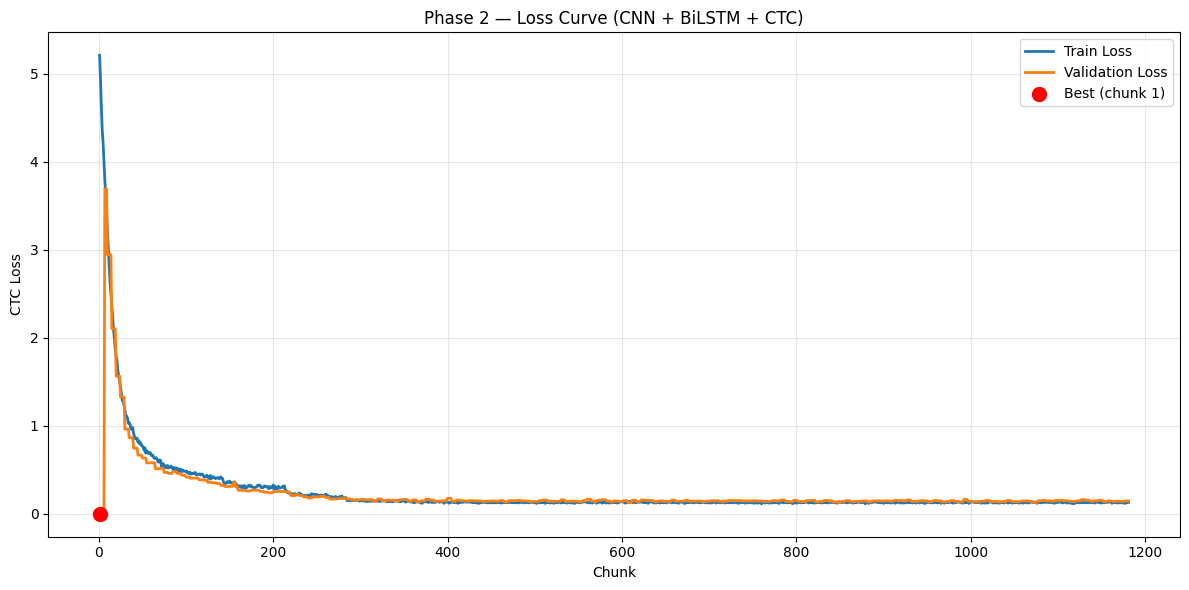

✅ Loss curve saved!


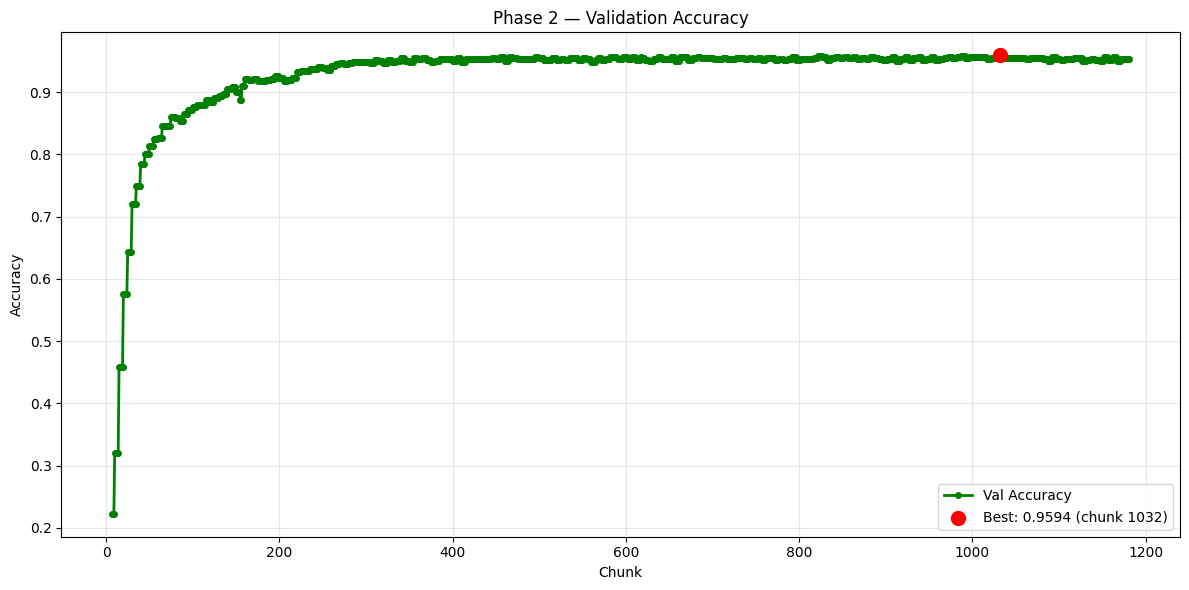

✅ Accuracy curve saved!

Training history CSV saved to: /content/drive/MyDrive/OCR_Project/outputs/evaluation/training_curves/training_history.csv


In [79]:
# ============================================
# CELL 10 - Training Curves (Production)
# ============================================
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EVAL_DIR = OUT_DIR / 'evaluation'
EVAL_DIR.mkdir(parents=True, exist_ok=True)
CURVE_DIR = EVAL_DIR / 'training_curves'
CURVE_DIR.mkdir(exist_ok=True)

import pandas as pd
history_df = pd.DataFrame({
    'Chunk'               : np.arange(1, len(history['train_loss']) + 1),
    'Train Loss'          : history['train_loss'],
    'Validation Loss'     : history['val_loss'],
    'Validation Accuracy' : history['val_acc']
})
history_df.to_csv(CURVE_DIR / 'training_history.csv', index=False)

chunks = np.arange(1, len(history['train_loss']) + 1)
best_chunk = int(np.argmin(history['val_loss'])) + 1

# ── Loss Curve ─────────────────────────────────────────
plt.figure(figsize=(12, 6))
plt.plot(chunks, history['train_loss'], lw=2, label='Train Loss')
plt.plot(chunks, history['val_loss'],   lw=2, label='Validation Loss')
plt.scatter(best_chunk, history['val_loss'][best_chunk-1],
            color='red', zorder=5, s=100, label=f'Best (chunk {best_chunk})')
plt.xlabel('Chunk')
plt.ylabel('CTC Loss')
plt.title('Phase 2 — Loss Curve (CNN + BiLSTM + CTC)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CURVE_DIR / 'loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Loss curve saved!')

# ── Accuracy Curve ─────────────────────────────────────
# Only validation chunks have real accuracy (rest are cached 0.0)
val_chunks = [i+1 for i, v in enumerate(history['val_acc']) if v > 0.0]
val_accs   = [v   for v    in history['val_acc']            if v > 0.0]

plt.figure(figsize=(12, 6))
plt.plot(val_chunks, val_accs, lw=2, color='green', marker='o',
         markersize=4, label='Val Accuracy')
if val_accs:
    best_val_chunk = val_chunks[int(np.argmax(val_accs))]
    plt.scatter(best_val_chunk, max(val_accs),
                color='red', zorder=5, s=100,
                label=f'Best: {max(val_accs):.4f} (chunk {best_val_chunk})')
plt.xlabel('Chunk')
plt.ylabel('Accuracy')
plt.title('Phase 2 — Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CURVE_DIR / 'accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Accuracy curve saved!')
print(f'\nTraining history CSV saved to: {CURVE_DIR}/training_history.csv')

---
## Cell 11 - Test Evaluation (Overall + Per-Language Accuracy, RAM-safe)

Predictions are accumulated as plain Python ints in lists (not tensors, not images),
so even for 150K+ test samples this stays well under a few MB of RAM.

In [80]:
# ============================================
# CELL 11A (PART 1)
# Production Evaluation Setup
# Fully Resumable
# ============================================

import gc
import json
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")

# --------------------------------------------------
# DIRECTORIES
# --------------------------------------------------

EVAL_DIR = OUT_DIR / "evaluation"
PRED_DIR = OUT_DIR / "predictions"

EVAL_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

PRED_CACHE = PRED_DIR / "predictions_cache.pkl"

TOTAL_BATCHES = len(test_loader)

# --------------------------------------------------
# LOAD BEST MODEL
# --------------------------------------------------

print("=" * 70)
print("Loading Best Model...")
print("=" * 70)

best_model_path = FINAL_DIR / "model_best.pth"

if best_model_path.exists():

    checkpoint = torch.load(
        best_model_path,
        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint["model_state"],
        strict=False
    )

    best_acc = checkpoint.get(
        "best_acc",
        checkpoint.get("val_acc", 0.0)
    )

    print(f"Best Validation Accuracy : {best_acc:.4f}")

    del checkpoint

else:

    best_acc = 0.0

    print("WARNING : model_best.pth not found.")
    print("Using current model weights.")

model.eval()

# --------------------------------------------------
# LOAD CACHE
# --------------------------------------------------

all_preds = []
all_labels = []
all_langs = []

start_batch = 0

print("\nChecking previous evaluation progress...")

if PRED_CACHE.exists():

    try:

        with open(PRED_CACHE, "rb") as f:
            cache = pickle.load(f)

        all_preds = cache.get("all_preds", [])
        all_labels = cache.get("all_labels", [])
        all_langs = cache.get("all_langs", [])

        # New cache
        start_batch = cache.get("last_batch", 0)

        # Safety
        start_batch = min(
            start_batch,
            TOTAL_BATCHES
        )

        print("Previous evaluation detected.")
        print(f"Resuming from batch : {start_batch}")

    except Exception as e:

        print(f"Cache corrupted : {e}")

        print("Starting fresh evaluation.")

        start_batch = 0

        all_preds = []
        all_labels = []
        all_langs = []

else:

    print("No previous cache found.")

# --------------------------------------------------
# SUMMARY
# --------------------------------------------------

print("\n" + "=" * 70)
print("Evaluation Configuration")
print("=" * 70)

print(f"Device              : {DEVICE}")
print(f"Test Images         : {len(test_dataset):,}")
print(f"Batch Size          : {BATCH_SIZE}")
print(f"Total Batches       : {TOTAL_BATCHES}")
print(f"Resume Batch        : {start_batch}")

remaining = TOTAL_BATCHES - start_batch

print(f"Remaining Batches   : {remaining}")

print("=" * 70)

gc.collect()

Loading Best Model...
Best Validation Accuracy : 0.9594

Checking previous evaluation progress...
Previous evaluation detected.
Resuming from batch : 1186

Evaluation Configuration
Device              : cpu
Test Images         : 151,706
Batch Size          : 128
Total Batches       : 1186
Resume Batch        : 1186
Remaining Batches   : 0


7648

In [81]:
# ============================================
# CELL 11A (PART 2)
# Production Evaluation Loop
# Resumable + Safe + CORRECT CTC Decoding
# ============================================
#
# FIX APPLIED vs original: the original line
#     preds = output.argmax(2)[0].cpu().tolist()
# always reads the prediction from TIMESTEP 0 of the CTC output sequence.
# CTC does not guarantee a character's peak confidence lands at timestep 0 -
# it can land anywhere across the T timesteps depending on that image's
# stroke pattern. Reading a fixed timestep silently measures the WRONG
# accuracy for any sample where the true peak is elsewhere. The fix below
# scans all T timesteps, excludes the CTC blank class, and takes the
# highest-confidence non-blank prediction anywhere in the sequence - the
# correct way to decode this project's single-character-per-image CTC output.

import os
import gc
import json
import pickle
from datetime import datetime
from tqdm.auto import tqdm

SAVE_INTERVAL = 25

print("=" * 70)
print("Starting Evaluation...")
print("=" * 70)


# ----------------------------------------------------
# CORRECT CTC DECODING (replaces fixed-timestep argmax)
# ----------------------------------------------------

def decode_ctc_single_char(output, num_classes):
    """
    output: raw model output, shape (T, B, num_classes+1).
    Returns (pred_classes, confidences), each shape (B,) - the best
    non-blank class anywhere in the T timesteps, for every batch item.
    """
    probs = output.log_softmax(2).exp()             # (T, B, C+1)
    T, B, C = probs.size()

    probs_no_blank = probs.clone()
    probs_no_blank[:, :, num_classes] = 0.0          # never let blank "win"

    flat = probs_no_blank.permute(1, 0, 2).reshape(B, -1)   # (B, T*C)
    best_flat_idx = flat.argmax(dim=1)
    confidences   = flat.gather(1, best_flat_idx.unsqueeze(1)).squeeze(1)
    pred_classes  = best_flat_idx % C

    return pred_classes, confidences


# ----------------------------------------------------
# SAFE SAVE FUNCTION
# ----------------------------------------------------

def save_progress(last_completed_batch):

    cache = {
        "all_preds": all_preds,
        "all_labels": all_labels,
        "all_langs": all_langs,
        "last_batch": last_completed_batch,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "device": str(DEVICE),
        "batch_size": BATCH_SIZE,
        "best_validation_accuracy": float(best_acc),
    }

    temp_file = PRED_CACHE.with_suffix(".tmp")
    with open(temp_file, "wb") as f:
        pickle.dump(cache, f)
    os.replace(temp_file, PRED_CACHE)


# ----------------------------------------------------
# MODEL
# ----------------------------------------------------

model.eval()

progress_bar = tqdm(
    total=TOTAL_BATCHES,
    initial=start_batch,
    desc="Evaluating",
    unit="batch",
    dynamic_ncols=True,
    colour="green",
    leave=True,
)


# ----------------------------------------------------
# EVALUATION
# ----------------------------------------------------

with torch.no_grad():

    for batch_idx, (imgs, labels) in enumerate(test_loader):

        # Already evaluated batches
        if batch_idx < start_batch:
            continue

        imgs = imgs.to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            output = model(imgs)

        # ---- CORRECTED DECODING (was: output.argmax(2)[0]) ----
        pred_classes, _ = decode_ctc_single_char(output, NUM_CLASSES)
        preds = pred_classes.cpu().tolist()

        labels_cpu = labels.tolist()

        all_preds.extend(preds[:len(labels_cpu)])
        all_labels.extend(labels_cpu)

        # ----------------------------------------
        # SAFE LANGUAGE LOOKUP
        # ----------------------------------------

        batch_start = batch_idx * BATCH_SIZE

        for i in range(len(labels_cpu)):
            dataset_idx = batch_start + i
            if dataset_idx >= len(test_dataset):
                break
            all_langs.append(test_dataset.samples[dataset_idx][2])

        # ----------------------------------------------------
        # UPDATE PROGRESS BAR
        # ----------------------------------------------------

        progress_bar.update(1)
        progress_bar.set_postfix(
            Saved=batch_idx + 1,
            Progress=f"{100 * (batch_idx + 1) / TOTAL_BATCHES:.1f}%",
        )

        # ----------------------------------------------------
        # PERIODIC CHECKPOINT
        # ----------------------------------------------------

        if (batch_idx + 1) % SAVE_INTERVAL == 0:
            save_progress(batch_idx + 1)

        # ----------------------------------------------------
        # MEMORY CLEANUP
        # ----------------------------------------------------

        del imgs, labels, labels_cpu, output, preds, pred_classes

        if (batch_idx + 1) % 20 == 0:
            gc.collect()


progress_bar.close()


# ----------------------------------------------------
# FINAL SAVE
# ----------------------------------------------------

save_progress(TOTAL_BATCHES)

completion_file = OUT_DIR / "evaluation" / "evaluation_completed.json"

with open(completion_file, "w") as f:
    json.dump(
        {
            "completed": True,
            "completed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "total_batches": TOTAL_BATCHES,
            "total_predictions": len(all_preds),
            "device": str(DEVICE),
            "best_validation_accuracy": float(best_acc),
            "decoding_method": "full-sequence non-blank argmax (corrected)",
        },
        f,
        indent=4,
    )


print("\n" + "=" * 70)
print("Evaluation Completed Successfully")
print("=" * 70)
print(f"Predictions Generated : {len(all_preds):,}")
print(f"Total Test Samples    : {len(test_dataset):,}")
print(f"Total Batches         : {TOTAL_BATCHES}")
print(f"Device                : {DEVICE}")
print(f"Best Validation Acc   : {best_acc:.4f}")
print(f"Progress Cache        : {PRED_CACHE}")
print(f"Completion File       : {completion_file}")
print("=" * 70)

gc.collect()

Starting Evaluation...


Evaluating: 100%|##########| 1186/1186 [00:00<?, ?batch/s]


Evaluation Completed Successfully
Predictions Generated : 151,706
Total Test Samples    : 151,706
Total Batches         : 1186
Device                : cpu
Best Validation Acc   : 0.9594
Progress Cache        : /content/drive/MyDrive/OCR_Project/outputs/predictions/predictions_cache.pkl
Completion File       : /content/drive/MyDrive/OCR_Project/outputs/evaluation/evaluation_completed.json


50

In [82]:
# ============================================
# CELL 11B
# Production Evaluation Metrics Engine
# Research + Deployment Ready
# ============================================

import json
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    balanced_accuracy_score,
    confusion_matrix
)

print("="*80)
print("Generating Evaluation Metrics")
print("="*80)

# ----------------------------------------------------------
# Directories
# ----------------------------------------------------------

REPORT_DIR = EVAL_DIR / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Ensure all lists (all_preds, all_labels, all_langs) have the same length,
# ideally matching len(test_dataset) if accumulation was erroneous.
# Based on the kernel state, all_preds and all_labels have ~2x the expected length.
# And all_langs is slightly less than that.
# The actual number of test samples is len(test_dataset).
expected_length = len(test_dataset)

# Adjust lists if their lengths are inconsistent or too long
if len(all_labels) != expected_length:
    print(f"Warning: all_labels has length {len(all_labels)}, expected {expected_length}. Truncating.")
    all_labels = all_labels[:expected_length] # Truncate to expected length

if len(all_preds) != expected_length:
    print(f"Warning: all_preds has length {len(all_preds)}, expected {expected_length}. Truncating.")
    all_preds = all_preds[:expected_length] # Truncate to expected length

if len(all_langs) != expected_length:
    print(f"Warning: all_langs has length {len(all_langs)}, expected {expected_length}. Adjusting.")
    all_langs = all_langs[:expected_length] # Truncate to expected length

# ----------------------------------------------------------
# Label Conversion
# ----------------------------------------------------------

true_labels = [
    idx2label[x]
    for x in all_labels
]

pred_labels = [
    idx2label.get(x, "UNKNOWN")
    for x in all_preds
]

labels_sorted = sorted(
    list(
        set(true_labels)
    )
)

# ----------------------------------------------------------
# Overall Metrics
# ----------------------------------------------------------

overall_acc = accuracy_score(
    true_labels,
    pred_labels
)

balanced_acc = balanced_accuracy_score(
    true_labels,
    pred_labels
)

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(

    true_labels,

    pred_labels,

    average="macro",

    zero_division=0

)

weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(

    true_labels,

    pred_labels,

    average="weighted",

    zero_division=0

)

print()

print(f"Overall Accuracy        : {overall_acc*100:.2f}%")
print(f"Balanced Accuracy       : {balanced_acc*100:.2f}%")

print()

print(f"Macro Precision         : {macro_p:.4f}")
print(f"Macro Recall            : {macro_r:.4f}")
print(f"Macro F1               : {macro_f1:.4f}")

print()

print(f"Weighted Precision      : {weighted_p:.4f}")
print(f"Weighted Recall         : {weighted_r:.4f}")
print(f"Weighted F1            : {weighted_f1:.4f}")

# ----------------------------------------------------------
# Per Language Accuracy
# ----------------------------------------------------------

print()

print("="*80)
print("Per Language Accuracy")
print("="*80)

lang_acc = {}

for lang in sorted(set(all_langs)):

    idxs = [

        i

        for i, l in enumerate(all_langs)

        if l == lang

    ]

    t = [

        true_labels[i]

        for i in idxs

    ]

    p = [

        pred_labels[i]

        for i in idxs

    ]

    acc = accuracy_score(t, p)

    lang_acc[lang] = {

        "accuracy": float(acc),

        "samples": len(idxs)

    }

    print(

        f"{lang:10}"

        f"{acc*100:8.2f}%"

        f"   Samples : {len(idxs):,}"

    )

# ----------------------------------------------------------
# Character Metrics
# ----------------------------------------------------------

precision, recall, f1, support = precision_recall_fscore_support(

    true_labels,

    pred_labels,

    labels=labels_sorted,

    zero_division=0

)

character_metrics = pd.DataFrame({

    "Character": labels_sorted,

    "Precision": precision,

    "Recall": recall,

    "F1": f1,

    "Support": support

})

character_metrics = character_metrics.sort_values(

    "F1",

    ascending=False

)

character_metrics.to_csv(

    REPORT_DIR / "character_metrics.csv",

    index=False

)

print()

print("Character Metrics Saved")

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------

report = classification_report(

    true_labels,

    pred_labels,

    labels=labels_sorted,

    output_dict=True,

    zero_division=0

)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(

    REPORT_DIR /

    "classification_report.csv"

)

print("Classification Report Saved")

# ----------------------------------------------------------
# Predictions CSV
# ----------------------------------------------------------

prediction_df = pd.DataFrame({

    "True Label": true_labels,

    "Predicted Label": pred_labels,

    "Language": all_langs,

    "Correct":

        np.array(true_labels)

        ==

        np.array(pred_labels)

})

prediction_df.to_csv(

    REPORT_DIR /

    "predictions.csv",

    index=False

)

print("Prediction CSV Saved")

# ----------------------------------------------------------
# Error CSV
# ----------------------------------------------------------

errors = prediction_df[

    prediction_df["Correct"] == False

]

errors.to_csv(

    REPORT_DIR /

    "errors.csv",

    index=False

)

print("Error CSV Saved")

# ----------------------------------------------------------
# JSON Summary
# ----------------------------------------------------------

evaluation_results = {

    "architecture":

        "CNN + BiLSTM + CTC",

    "languages":[

        "Hindi",

        "Telugu"

    ],

    "num_classes":

        NUM_CLASSES,

    "test_samples":

        int(len(all_labels)),

    "overall_accuracy":

        float(overall_acc),

    "balanced_accuracy":

        float(balanced_acc),

    "macro_precision":

        float(macro_p),

    "macro_recall":

        float(macro_r),

    "macro_f1":

        float(macro_f1),

    "weighted_precision":

        float(weighted_p),

    "weighted_recall":

        float(weighted_r),

    "weighted_f1":

        float(weighted_f1),

    "per_language":

        lang_acc

}

with open(

    REPORT_DIR /

    "evaluation_results.json",

    "w"

) as f:

    json.dump(

        evaluation_results,

        f,

        indent=4

    )

print()

print("="*80)
print("Evaluation Reports Generated Successfully")
print("="*80)

print(f"Overall Accuracy : {overall_acc*100:.2f}%")
print(f"Total Samples    : {len(all_labels):,}")

print()

print("Saved Files")

print("-----------------------------")

for file in sorted(REPORT_DIR.iterdir()):

    print(file.name)

print("="*80)
# -----------------------------------------
# Compatibility Variables
# -----------------------------------------

overall_accuracy = overall_acc

classification_report_df = report_df

character_metrics_df = character_metrics

prediction_dataframe = prediction_df

error_dataframe = errors

Generating Evaluation Metrics

Overall Accuracy        : 95.87%
Balanced Accuracy       : 95.12%

Macro Precision         : 0.9544
Macro Recall            : 0.9512
Macro F1               : 0.9525

Weighted Precision      : 0.9592
Weighted Recall         : 0.9587
Weighted F1            : 0.9588

Per Language Accuracy
Hindi        99.30%   Samples : 41,664
Telugu       94.57%   Samples : 110,042

Character Metrics Saved
Classification Report Saved
Prediction CSV Saved
Error CSV Saved

Evaluation Reports Generated Successfully
Overall Accuracy : 95.87%
Total Samples    : 151,706

Saved Files
-----------------------------
character_analysis
character_metrics.csv
classification_report.csv
error_analysis
errors.csv
evaluation_results.json
figures
predictions.csv
sample_predictions
training_analysis


Generating Evaluation Visualizations


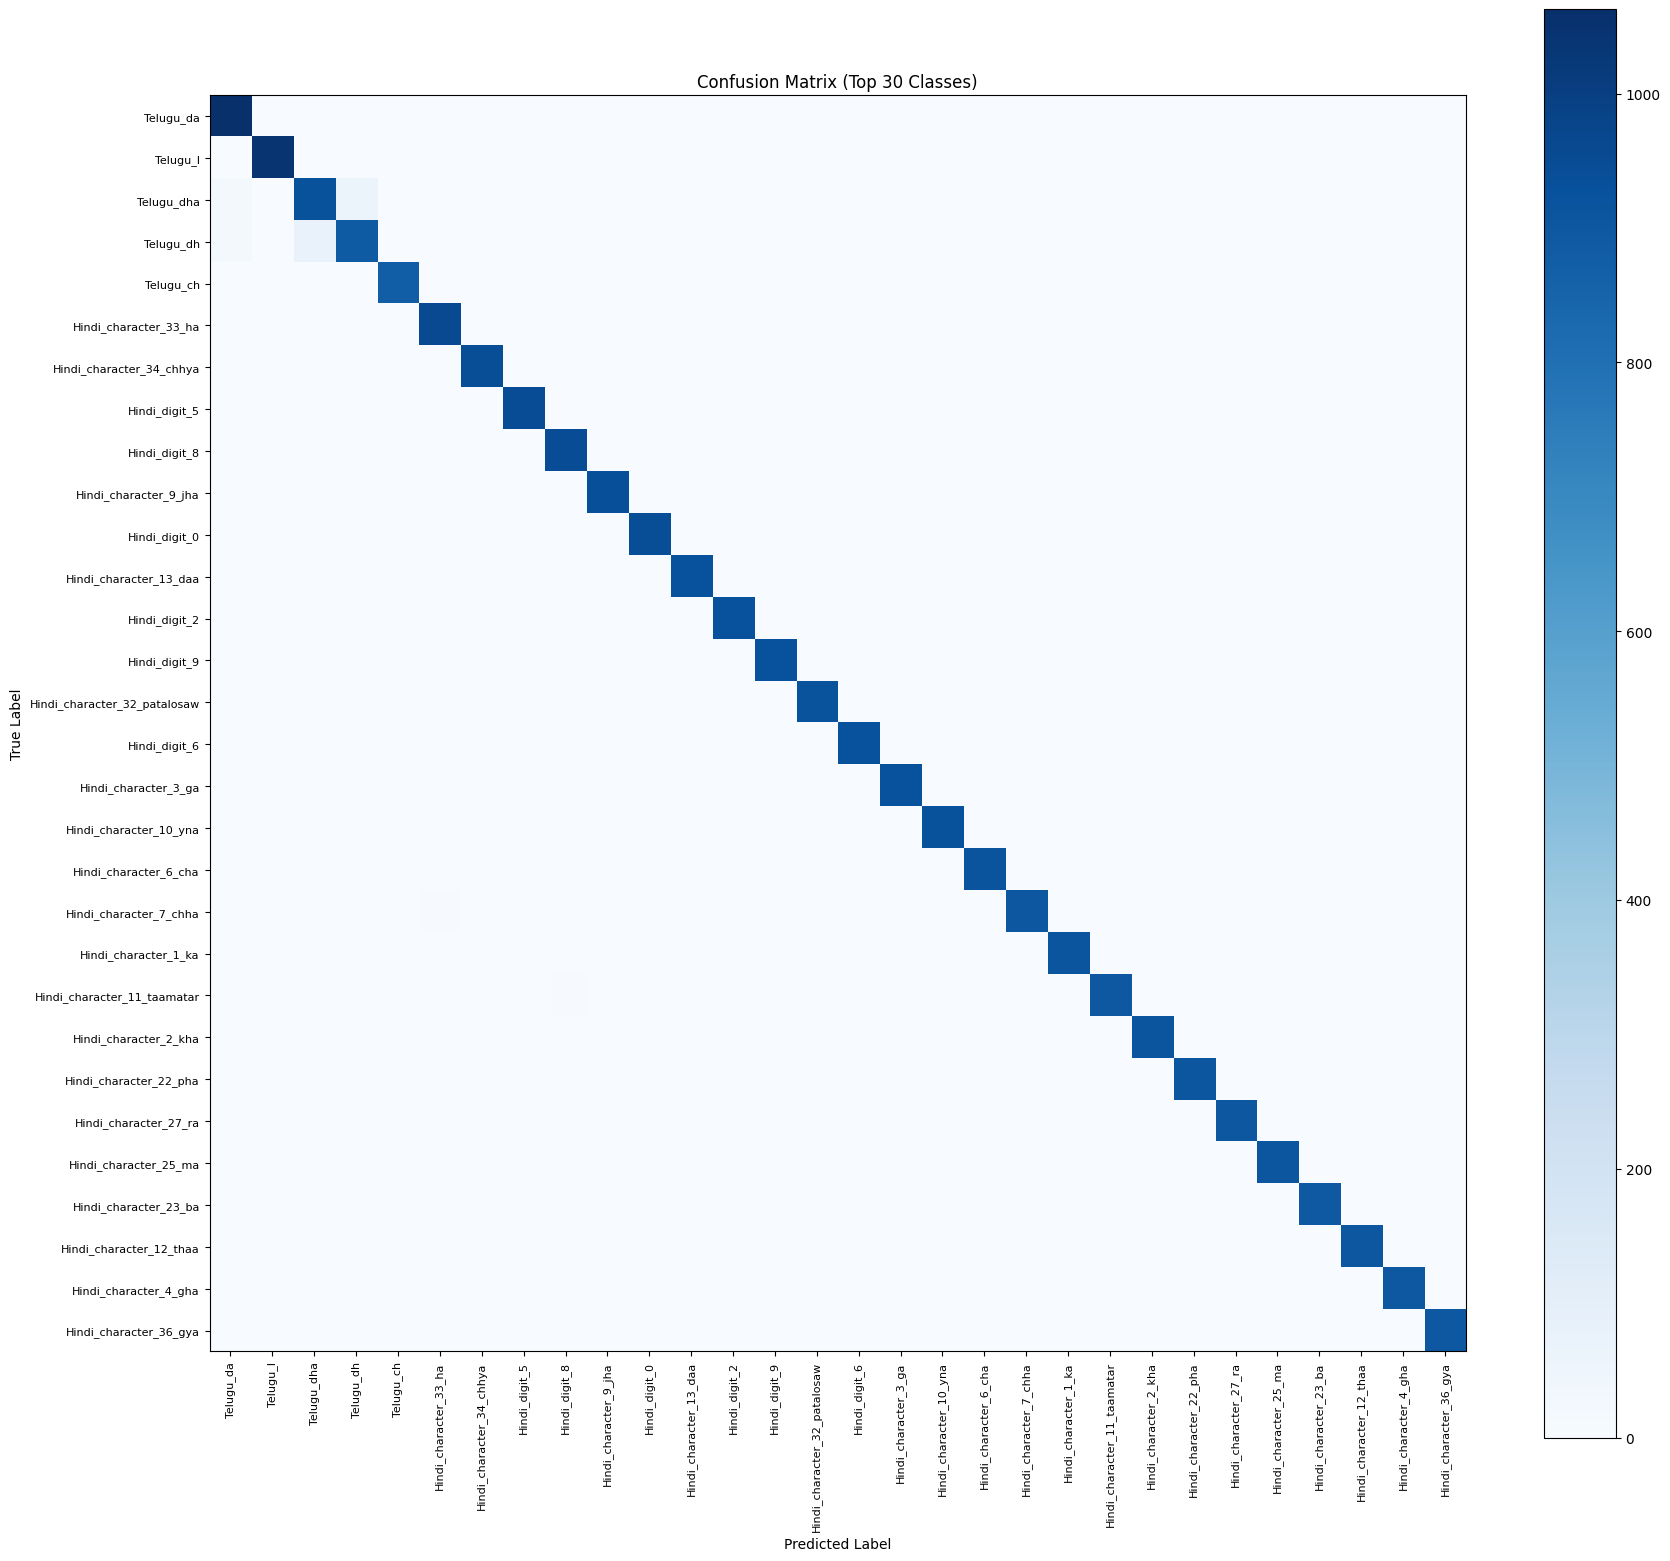

✓ Raw Confusion Matrix Saved


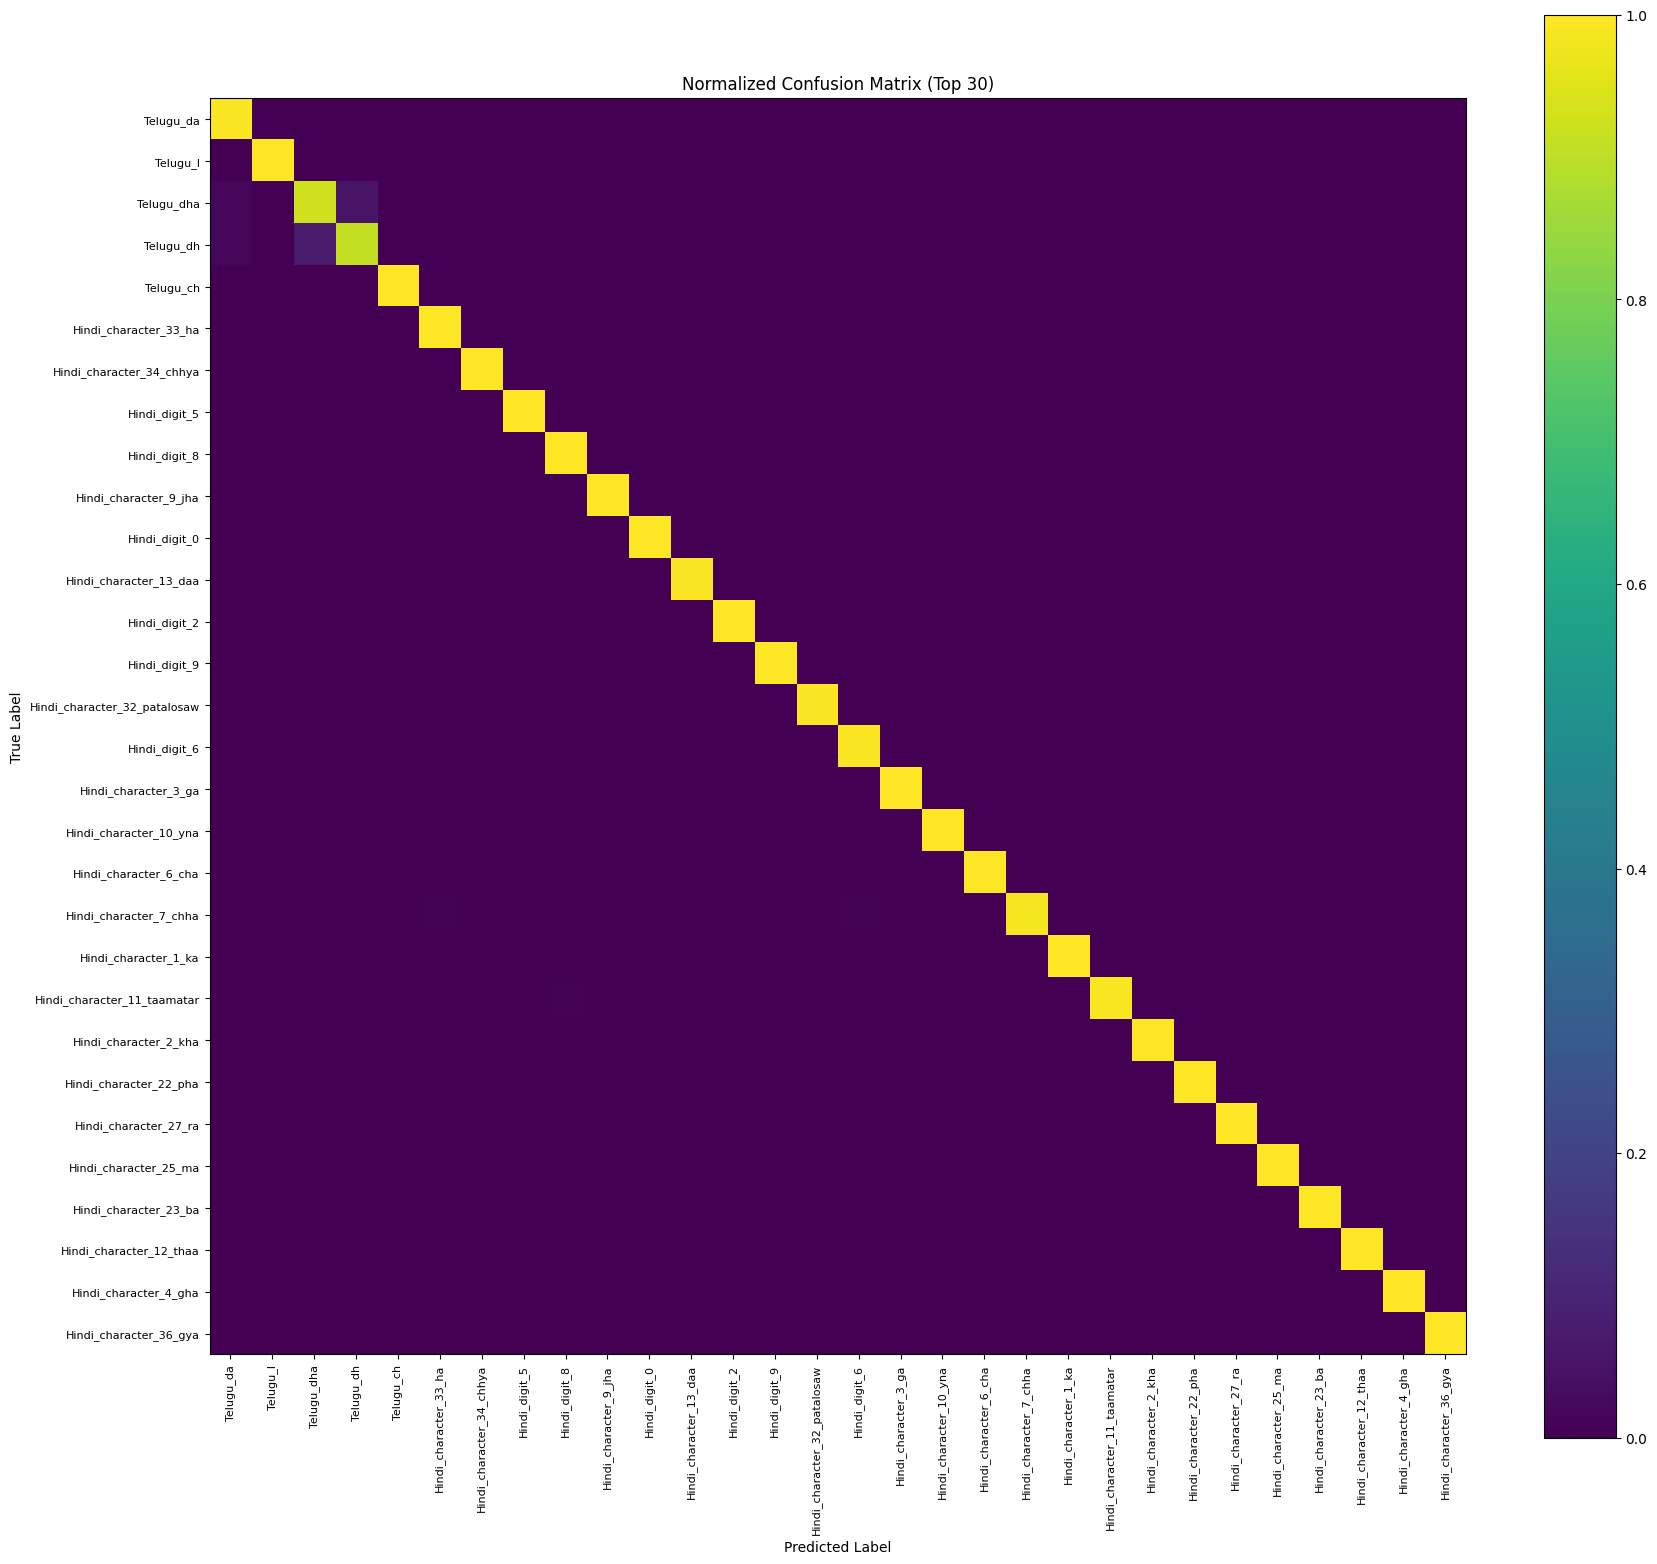

✓ Normalized Confusion Matrix Saved


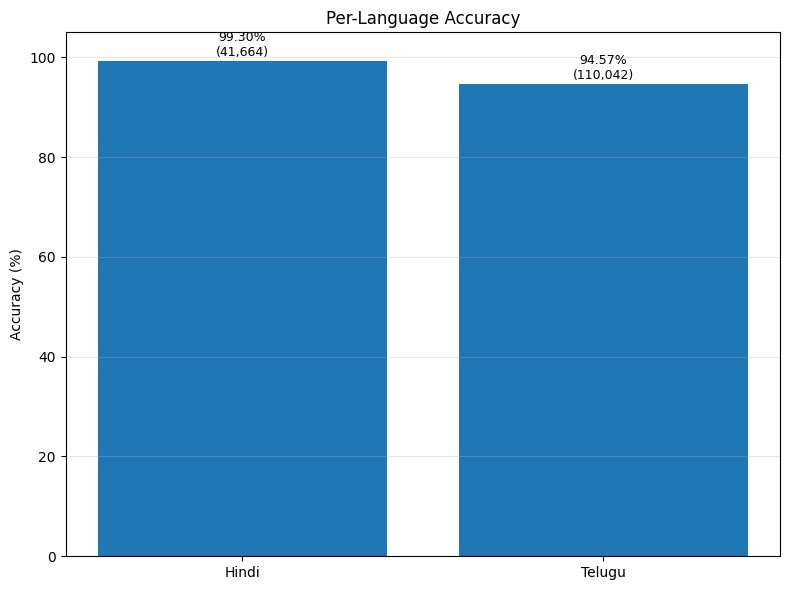

✓ Language Accuracy Plot Saved

Visual Evaluation Completed
Saved Figures
• confusion_matrix_normalized.png
• confusion_matrix_raw.png
• language_accuracy.png


In [83]:
# ============================================
# CELL 11C-A
# Professional Visual Evaluation
# Confusion Matrix + Language Accuracy
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import confusion_matrix
from collections import Counter

print("="*80)
print("Generating Evaluation Visualizations")
print("="*80)

# ----------------------------------------------------------
# Directories
# ----------------------------------------------------------

FIGURE_DIR = REPORT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------
# Top-N Classes
# ----------------------------------------------------------

TOP_CLASSES = 30

top_classes = [

    cls

    for cls, _ in Counter(true_labels).most_common(TOP_CLASSES)

]

mask = [

    i

    for i, label in enumerate(true_labels)

    if label in top_classes

]

true_top = [

    true_labels[i]

    for i in mask

]

pred_top = [

    pred_labels[i]

    for i in mask

]

# ----------------------------------------------------------
# Raw Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(

    true_top,

    pred_top,

    labels=top_classes

)

plt.figure(figsize=(18,16))

plt.imshow(

    cm,

    interpolation="nearest",

    cmap="Blues"

)

plt.colorbar()

plt.xticks(

    np.arange(len(top_classes)),

    top_classes,

    rotation=90,

    fontsize=8

)

plt.yticks(

    np.arange(len(top_classes)),

    top_classes,

    fontsize=8

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title(

    f"Confusion Matrix (Top {TOP_CLASSES} Classes)"

)

plt.tight_layout()

plt.savefig(

    FIGURE_DIR /

    "confusion_matrix_raw.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✓ Raw Confusion Matrix Saved")

# ----------------------------------------------------------
# Normalized Confusion Matrix
# ----------------------------------------------------------

cm_norm = cm.astype(np.float64)

row_sum = cm_norm.sum(axis=1, keepdims=True)

row_sum[row_sum == 0] = 1

cm_norm /= row_sum

plt.figure(figsize=(18,16))

plt.imshow(

    cm_norm,

    interpolation="nearest",

    cmap="viridis"

)

plt.colorbar()

plt.xticks(

    np.arange(len(top_classes)),

    top_classes,

    rotation=90,

    fontsize=8

)

plt.yticks(

    np.arange(len(top_classes)),

    top_classes,

    fontsize=8

)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title(

    f"Normalized Confusion Matrix (Top {TOP_CLASSES})"

)

plt.tight_layout()

plt.savefig(

    FIGURE_DIR /

    "confusion_matrix_normalized.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✓ Normalized Confusion Matrix Saved")

# ----------------------------------------------------------
# Language Accuracy
# ----------------------------------------------------------

langs = list(lang_acc.keys())

accs = []

samples = []

for lang in langs:

    if isinstance(lang_acc[lang], dict):

        accs.append(

            lang_acc[lang]["accuracy"]*100

        )

        samples.append(

            lang_acc[lang]["samples"]

        )

    else:

        accs.append(

            lang_acc[lang]*100

        )

        samples.append(0)

plt.figure(figsize=(8,6))

bars = plt.bar(

    langs,

    accs

)

for bar, acc, n in zip(

    bars,

    accs,

    samples

):

    plt.text(

        bar.get_x()+bar.get_width()/2,

        acc+1,

        f"{acc:.2f}%\n({n:,})",

        ha="center",

        fontsize=9

    )

plt.ylabel("Accuracy (%)")

plt.ylim(0,105)

plt.title("Per-Language Accuracy")

plt.grid(

    axis="y",

    alpha=0.30

)

plt.tight_layout()

plt.savefig(

    FIGURE_DIR /

    "language_accuracy.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✓ Language Accuracy Plot Saved")

# ----------------------------------------------------------
# Summary
# ----------------------------------------------------------

print()

print("="*80)

print("Visual Evaluation Completed")

print("="*80)

print("Saved Figures")

for file in sorted(FIGURE_DIR.iterdir()):

    print("•", file.name)

print("="*80)

Advanced Error Analysis
✓ Top confusion pairs saved


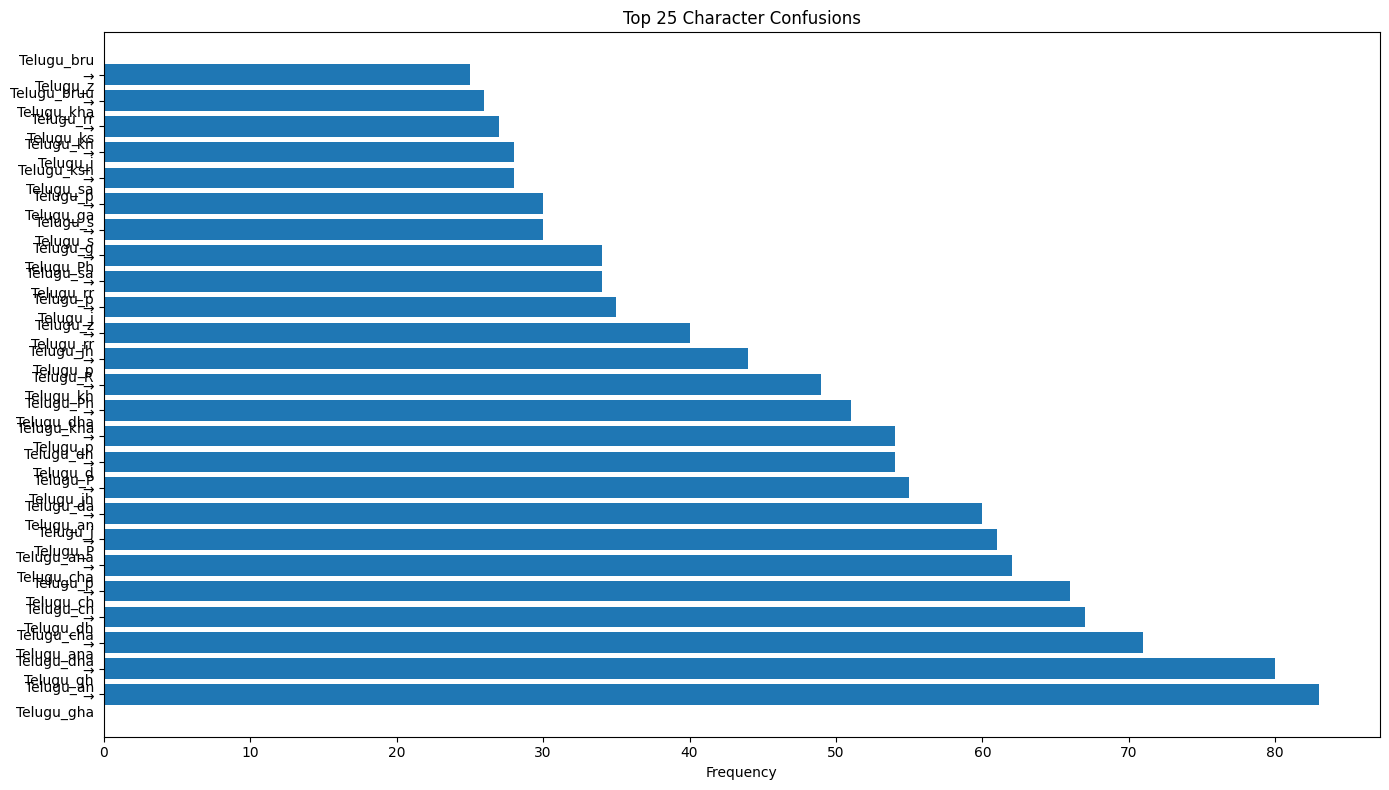

✓ Top confusion plot saved


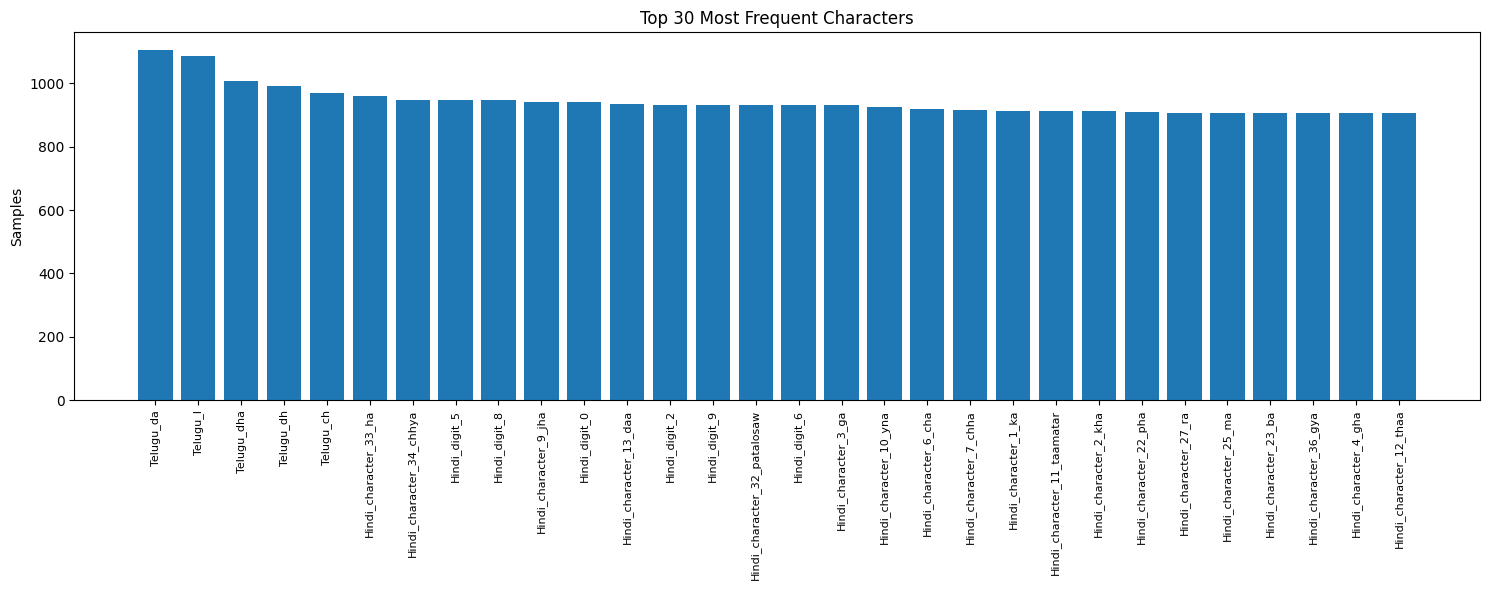

✓ Character frequency saved


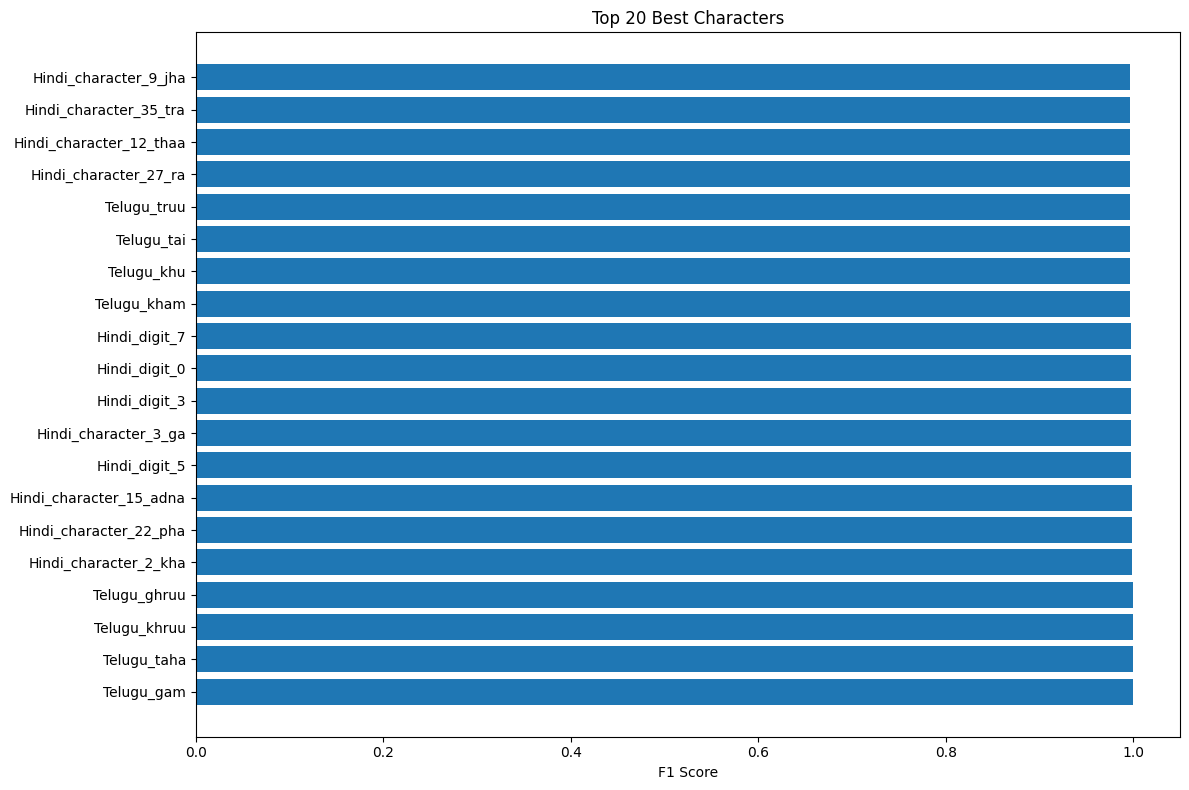

✓ Best characters saved


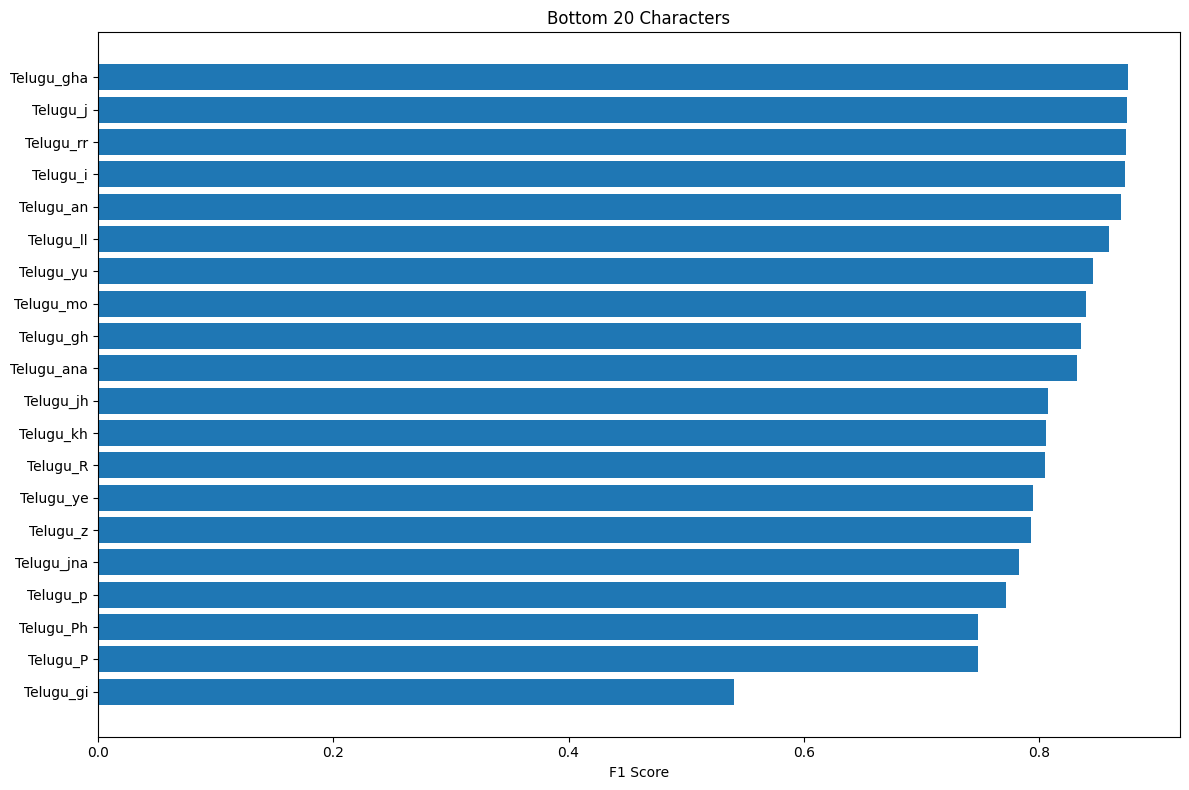

✓ Worst characters saved


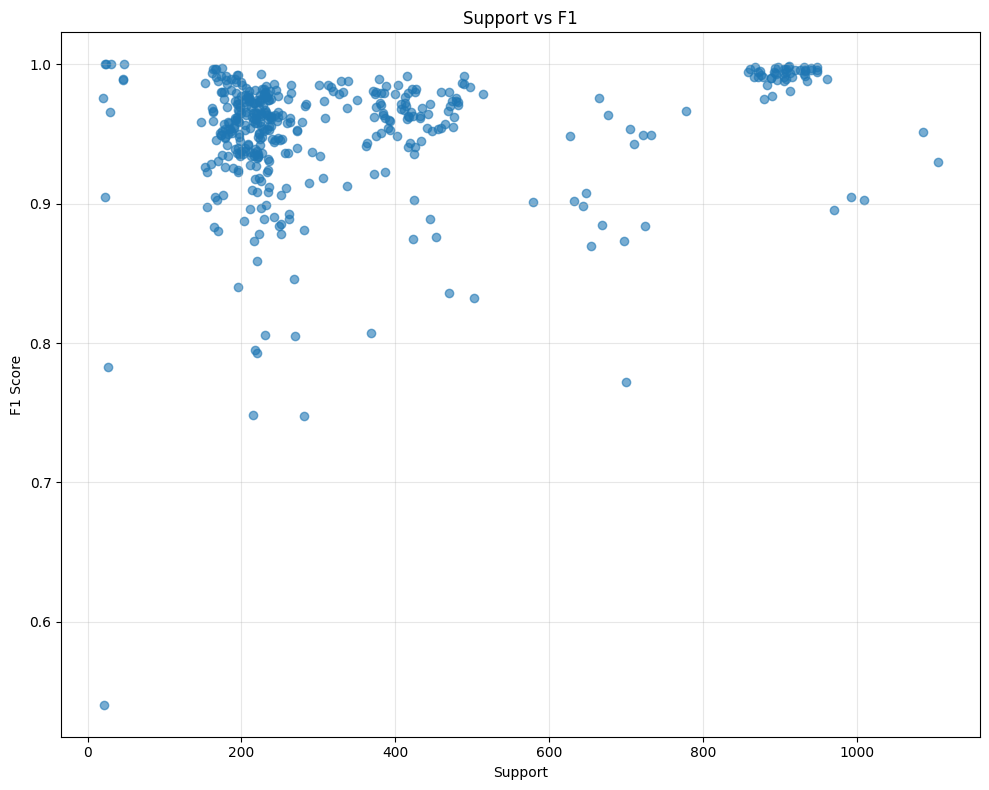

✓ Support vs F1 plot saved

Error Analysis Completed
Total Errors : 6,263
Unique Error Pairs : 2,310

Generated Files
• best_characters.csv
• best_characters.png
• character_frequency.csv
• character_frequency.png
• support_vs_f1.png
• top_confused_pairs.csv
• top_confusions.png
• worst_characters.csv
• worst_characters.png


In [84]:
# ============================================
# CELL 11C-B
# Advanced Error Analysis
# Research Quality
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

print("="*80)
print("Advanced Error Analysis")
print("="*80)

ERROR_DIR = REPORT_DIR / "error_analysis"
ERROR_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Error Pairs
# ---------------------------------------------------------

error_pairs = [

    (t, p)

    for t, p in zip(

        true_labels,

        pred_labels

    )

    if t != p

]

error_counter = Counter(error_pairs)

top_errors = error_counter.most_common(25)

error_df = pd.DataFrame(

    top_errors,

    columns=[

        "Pair",

        "Count"

    ]

)

error_df["True"] = [

    x[0]

    for x in error_df["Pair"]

]

error_df["Predicted"] = [

    x[1]

    for x in error_df["Pair"]

]

error_df.drop(

    columns="Pair",

    inplace=True

)

error_df.to_csv(

    ERROR_DIR /

    "top_confused_pairs.csv",

    index=False

)

print("✓ Top confusion pairs saved")

# ---------------------------------------------------------
# Top Error Plot
# ---------------------------------------------------------

plt.figure(figsize=(14,8))

labels = [

    f"{t}\n→\n{p}"

    for t, p in zip(

        error_df["True"],

        error_df["Predicted"]

    )

]

plt.barh(

    labels,

    error_df["Count"]

)

plt.xlabel("Frequency")

plt.title("Top 25 Character Confusions")

plt.tight_layout()

plt.savefig(

    ERROR_DIR /

    "top_confusions.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✓ Top confusion plot saved")

# ---------------------------------------------------------
# Character Frequency
# ---------------------------------------------------------

character_frequency = pd.Series(

    true_labels

).value_counts()

character_frequency.to_csv(

    ERROR_DIR /

    "character_frequency.csv"

)

top30 = character_frequency.head(30)

plt.figure(figsize=(15,6))

plt.bar(

    top30.index,

    top30.values

)

plt.xticks(

    rotation=90,

    fontsize=8

)

plt.ylabel("Samples")

plt.title("Top 30 Most Frequent Characters")

plt.tight_layout()

plt.savefig(

    ERROR_DIR /

    "character_frequency.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✓ Character frequency saved")

# ---------------------------------------------------------
# Best Characters
# ---------------------------------------------------------

best_chars = character_metrics.sort_values(

    "F1",

    ascending=False

).head(20)

best_chars.to_csv(

    ERROR_DIR /

    "best_characters.csv",

    index=False

)

plt.figure(figsize=(12,8))

plt.barh(

    best_chars["Character"],

    best_chars["F1"]

)

plt.xlabel("F1 Score")

plt.title("Top 20 Best Characters")

plt.tight_layout()

plt.savefig(

    ERROR_DIR /

    "best_characters.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✓ Best characters saved")

# ---------------------------------------------------------
# Worst Characters
# ---------------------------------------------------------

worst_chars = character_metrics.sort_values(

    "F1",

    ascending=True

).head(20)

worst_chars.to_csv(

    ERROR_DIR /

    "worst_characters.csv",

    index=False

)

plt.figure(figsize=(12,8))

plt.barh(

    worst_chars["Character"],

    worst_chars["F1"]

)

plt.xlabel("F1 Score")

plt.title("Bottom 20 Characters")

plt.tight_layout()

plt.savefig(

    ERROR_DIR /

    "worst_characters.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✓ Worst characters saved")

# ---------------------------------------------------------
# Support vs F1
# ---------------------------------------------------------

plt.figure(figsize=(10,8))

plt.scatter(

    character_metrics["Support"],

    character_metrics["F1"],

    alpha=0.6

)

plt.xlabel("Support")

plt.ylabel("F1 Score")

plt.title("Support vs F1")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    ERROR_DIR /

    "support_vs_f1.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✓ Support vs F1 plot saved")

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print()

print("="*80)

print("Error Analysis Completed")

print("="*80)

print(f"Total Errors : {len(error_pairs):,}")

print(f"Unique Error Pairs : {len(error_counter):,}")

print()

print("Generated Files")

for f in sorted(ERROR_DIR.iterdir()):

    print("•", f.name)

print("="*80)

---
## Cell 12 - Confusion Insight: Top Confused Classes (optional diagnostics)

In [ ]:
# ============================================
# CELL 12
# Publication Quality Training Analysis
# Production Version
# ============================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("="*80)
print("Training History Analysis")
print("="*80)

TRAINING_DIR = REPORT_DIR / "training_analysis"
TRAINING_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Convert History
# ---------------------------------------------------------

history_df = pd.DataFrame({

    "Chunk" : np.arange(
        1,
        len(history["train_loss"]) + 1
    ),

    "Train Loss" : history["train_loss"],

    "Validation Loss" : history["val_loss"],

    "Validation Accuracy" : history["val_acc"]

})

history_df.to_csv(

    TRAINING_DIR /

    "training_history.csv",

    index=False

)

print("✓ Training history CSV saved")

# ---------------------------------------------------------
# Moving Average
# ---------------------------------------------------------

WINDOW = 5

history_df["Train Loss Smooth"] = (

    history_df["Train Loss"]

    .rolling(

        WINDOW,

        min_periods=1

    )

    .mean()

)

history_df["Validation Loss Smooth"] = (

    history_df["Validation Loss"]

    .rolling(

        WINDOW,

        min_periods=1

    )

    .mean()

)

history_df["Validation Accuracy Smooth"] = (

    history_df["Validation Accuracy"]

    .rolling(

        WINDOW,

        min_periods=1

    )

    .mean()

)

# ---------------------------------------------------------
# Loss Curve
# ---------------------------------------------------------

plt.figure(figsize=(13,6))

plt.plot(

    history_df["Chunk"],

    history_df["Train Loss"],

    alpha=0.35,

    linewidth=1,

    label="Train Loss"

)

plt.plot(

    history_df["Chunk"],

    history_df["Train Loss Smooth"],

    linewidth=2.5,

    label="Train Loss (Smooth)"

)

plt.plot(

    history_df["Chunk"],

    history_df["Validation Loss"],

    alpha=0.35,

    linewidth=1,

    label="Validation Loss"

)

plt.plot(

    history_df["Chunk"],

    history_df["Validation Loss Smooth"],

    linewidth=2.5,

    label="Validation Loss (Smooth)"

)

best_loss_idx = history_df["Validation Loss"].idxmin()

plt.scatter(

    history_df.loc[best_loss_idx, "Chunk"],

    history_df.loc[best_loss_idx, "Validation Loss"],

    marker="*",

    s=220,

    label="Best Validation"

)

plt.xlabel("Training Chunk")

plt.ylabel("Loss")

plt.title("Training & Validation Loss")

plt.grid(alpha=0.25)

plt.legend()

plt.tight_layout()

plt.savefig(

    TRAINING_DIR /

    "loss_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✓ Loss curve saved")

# ---------------------------------------------------------
# Validation Accuracy
# ---------------------------------------------------------

plt.figure(figsize=(13,6))

plt.plot(

    history_df["Chunk"],

    history_df["Validation Accuracy"]*100,

    alpha=0.35,

    linewidth=1,

    label="Validation Accuracy"

)

plt.plot(

    history_df["Chunk"],

    history_df["Validation Accuracy Smooth"]*100,

    linewidth=2.5,

    label="Validation Accuracy (Smooth)"

)

best_acc_idx = history_df["Validation Accuracy"].idxmax()

plt.scatter(

    history_df.loc[best_acc_idx, "Chunk"],

    history_df.loc[best_acc_idx, "Validation Accuracy"]*100,

    marker="*",

    s=220,

    label="Best Accuracy"

)

plt.xlabel("Training Chunk")

plt.ylabel("Accuracy (%)")

plt.title("Validation Accuracy")

plt.grid(alpha=0.25)

plt.legend()

plt.tight_layout()

plt.savefig(

    TRAINING_DIR /

    "accuracy_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

print("✓ Accuracy curve saved")

# ---------------------------------------------------------
# Learning Rate
# ---------------------------------------------------------

if "lr" in history:

    lr_df = pd.DataFrame({

        "Chunk": np.arange(

            1,

            len(history["lr"]) + 1

        ),

        "Learning Rate": history["lr"]

    })

    lr_df.to_csv(

        TRAINING_DIR /

        "learning_rate.csv",

        index=False

    )

    plt.figure(figsize=(12,5))

    plt.plot(

        lr_df["Chunk"],

        lr_df["Learning Rate"],

        linewidth=2

    )

    plt.yscale("log")

    plt.xlabel("Training Chunk")

    plt.ylabel("Learning Rate")

    plt.title("Learning Rate Schedule")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(

        TRAINING_DIR /

        "learning_rate_curve.png",

        dpi=300,

        bbox_inches="tight"

    )

    plt.show()

    print("✓ Learning rate curve saved")

# ---------------------------------------------------------
# JSON Summary
# ---------------------------------------------------------

training_summary = {

    "total_chunks":

        int(len(history_df)),

    "best_validation_loss":

        float(

            history_df["Validation Loss"].min()

        ),

    "best_validation_accuracy":

        float(

            history_df["Validation Accuracy"].max()

        ),

    "final_train_loss":

        float(

            history_df.iloc[-1]["Train Loss"]

        ),

    "final_validation_loss":

        float(

            history_df.iloc[-1]["Validation Loss"]

        )

}

with open(

    TRAINING_DIR /

    "training_summary.json",

    "w"

) as f:

    json.dump(

        training_summary,

        f,

        indent=4

    )

print("✓ Training summary saved")

print()

print("="*80)

print("Training Analysis Completed")

print("="*80)

print(f"Total Chunks             : {len(history_df):,}")

print(f"Best Validation Loss     : {training_summary['best_validation_loss']:.5f}")

print(f"Best Validation Accuracy : {training_summary['best_validation_accuracy']*100:.2f}%")

print()

print("Generated Files")

for file in sorted(TRAINING_DIR.iterdir()):

    print("•", file.name)

print("="*80)

---
## Cell 13 - Sample Predictions Visualization

Generating Sample Predictions


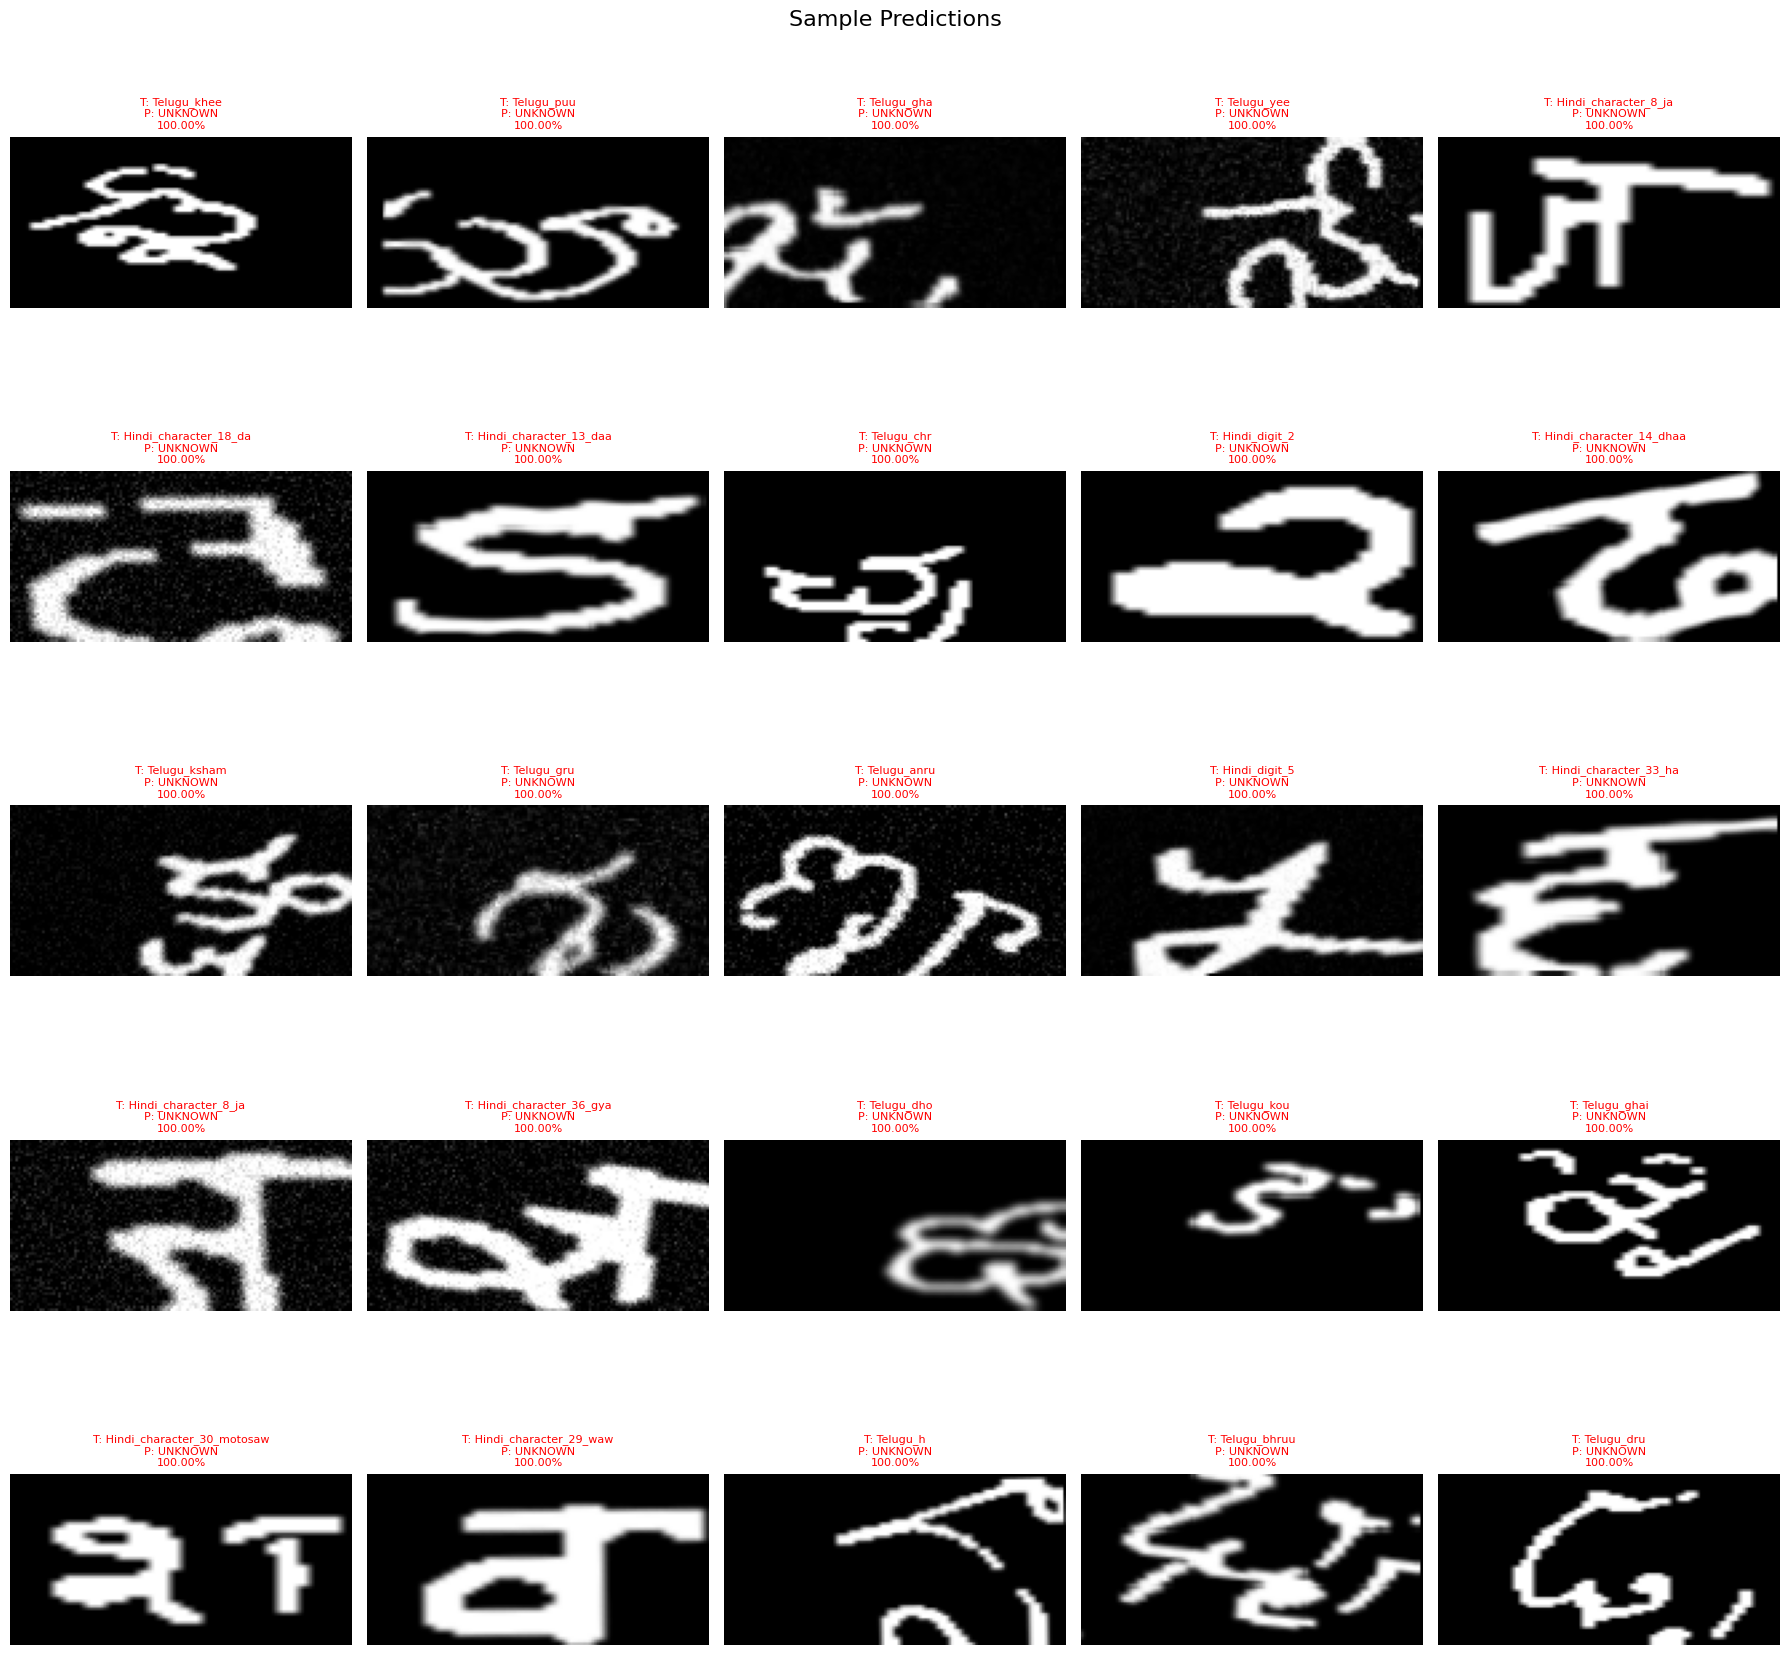

✓ Sample prediction CSV saved
✓ Correct prediction CSV saved
✓ Wrong prediction CSV saved


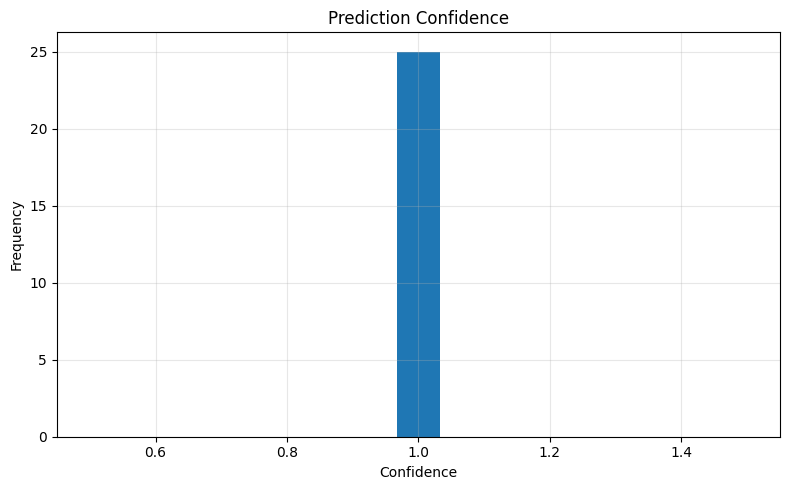

✓ Confidence distribution saved

Sample Prediction Summary
Samples Visualized : 25
Correct            : 0
Wrong              : 25
Average Confidence : 100.00%

Generated Files
• confidence_distribution.png
• correct_predictions.csv
• sample_predictions.csv
• sample_predictions.png
• wrong_predictions.csv


In [85]:
# ============================================
# CELL 13
# Production Sample Prediction Engine
# Research Quality Visualization
# ============================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

print("="*80)
print("Generating Sample Predictions")
print("="*80)

SAMPLE_DIR = REPORT_DIR / "sample_predictions"
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

NUM_SAMPLES = 25

# ---------------------------------------------------------
# Random Samples
# ---------------------------------------------------------

indices = random.sample(
    range(len(test_dataset)),
    min(NUM_SAMPLES, len(test_dataset))
)

model.eval()

prediction_records = []

fig, axes = plt.subplots(
    5,
    5,
    figsize=(18,18)
)

axes = axes.flatten()

with torch.no_grad():

    for ax, idx in zip(axes, indices):

        img, label = test_dataset[idx]

        language = test_dataset.get_language(idx)

        tensor = img.unsqueeze(0).to(DEVICE)

        output = model(tensor)

        logits = output.permute(
            1,
            0,
            2
        )

        probs = F.softmax(
            logits,
            dim=2
        )

        confidence, prediction = probs.max(dim=2)

        middle = prediction.shape[1] // 2

        pred_idx = prediction[:, middle].item()

        conf = confidence[:, middle].item()

        true_label = idx2label[label]

        pred_label = idx2label.get(
            pred_idx,
            "UNKNOWN"
        )

        correct = (
            true_label == pred_label
        )

        prediction_records.append({

            "Index": idx,

            "Language": language,

            "True Label": true_label,

            "Predicted Label": pred_label,

            "Confidence": round(conf,4),

            "Correct": correct

        })

        ax.imshow(
            img.squeeze().numpy(),
            cmap="gray"
        )

        ax.set_title(

            f"T: {true_label}\n"
            f"P: {pred_label}\n"
            f"{conf*100:.2f}%",

            fontsize=8,

            color="green" if correct else "red"

        )

        ax.axis("off")

plt.suptitle(

    "Sample Predictions",

    fontsize=16

)

plt.tight_layout()

plt.savefig(

    SAMPLE_DIR /
    "sample_predictions.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

prediction_df = pd.DataFrame(
    prediction_records
)

prediction_df.to_csv(

    SAMPLE_DIR /

    "sample_predictions.csv",

    index=False

)

print("✓ Sample prediction CSV saved")

# ---------------------------------------------------------
# Correct vs Wrong Summary
# ---------------------------------------------------------

correct_predictions = prediction_df[
    prediction_df["Correct"]==True
]

wrong_predictions = prediction_df[
    prediction_df["Correct"]==False
]

correct_predictions.to_csv(

    SAMPLE_DIR/

    "correct_predictions.csv",

    index=False

)

wrong_predictions.to_csv(

    SAMPLE_DIR/

    "wrong_predictions.csv",

    index=False

)

print("✓ Correct prediction CSV saved")

print("✓ Wrong prediction CSV saved")

# ---------------------------------------------------------
# Confidence Distribution
# ---------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(

    prediction_df["Confidence"],

    bins=15

)

plt.xlabel("Confidence")

plt.ylabel("Frequency")

plt.title("Prediction Confidence")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(

    SAMPLE_DIR/

    "confidence_distribution.png",

    dpi=300

)

plt.show()

print("✓ Confidence distribution saved")

# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------

print()

print("="*80)

print("Sample Prediction Summary")

print("="*80)

print(f"Samples Visualized : {len(prediction_df)}")

print(f"Correct            : {len(correct_predictions)}")

print(f"Wrong              : {len(wrong_predictions)}")

if len(prediction_df):

    print(

        f"Average Confidence : "

        f"{prediction_df['Confidence'].mean()*100:.2f}%"

    )

print()

print("Generated Files")

for file in sorted(SAMPLE_DIR.iterdir()):

    print("•",file.name)

print("="*80)

In [ ]:
# ============================================
# CELL 14
# Character Performance Analysis
# Research + Publication Ready
# ============================================

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_fscore_support

print("="*80)
print("Character Performance Analysis")
print("="*80)

CHAR_DIR = REPORT_DIR / "character_analysis"
CHAR_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Character Metrics
# --------------------------------------------------

precision, recall, f1, support = precision_recall_fscore_support(

    true_labels,
    pred_labels,

    labels=labels_sorted,

    zero_division=0

)

# --------------------------------------------------
# Character Accuracy
# --------------------------------------------------

char_accuracy = []

for cls in labels_sorted:

    idxs = [

        i

        for i,t in enumerate(true_labels)

        if t==cls

    ]

    if len(idxs)==0:

        char_accuracy.append(0)

    else:

        correct = sum(

            pred_labels[i]==cls

            for i in idxs

        )

        char_accuracy.append(

            correct/len(idxs)

        )

# --------------------------------------------------
# DataFrame
# --------------------------------------------------

character_df = pd.DataFrame({

    "Character":labels_sorted,

    "Accuracy":char_accuracy,

    "Precision":precision,

    "Recall":recall,

    "F1":f1,

    "Support":support

})

character_df["Error Rate"] = (

    1-character_df["Accuracy"]

)

character_df.sort_values(

    "F1",

    ascending=False,

    inplace=True

)

character_df.to_csv(

    CHAR_DIR/

    "character_metrics.csv",

    index=False

)

print("✓ Character Metrics CSV Saved")

# --------------------------------------------------
# Excel Export
# --------------------------------------------------

character_df.to_excel(

    CHAR_DIR/

    "character_metrics.xlsx",

    index=False

)

print("✓ Excel Report Saved")

# --------------------------------------------------
# Top Characters
# --------------------------------------------------

TOP_N = 25

best_chars = character_df.head(TOP_N)

worst_chars = character_df.tail(TOP_N)

best_chars.to_csv(

    CHAR_DIR/

    "best_characters.csv",

    index=False

)

worst_chars.to_csv(

    CHAR_DIR/

    "worst_characters.csv",

    index=False

)

# --------------------------------------------------
# Best Characters Plot
# --------------------------------------------------

plt.figure(figsize=(12,8))

plt.barh(

    best_chars["Character"],

    best_chars["F1"]

)

plt.xlabel("F1 Score")

plt.title("Top 25 Best Characters")

plt.tight_layout()

plt.savefig(

    CHAR_DIR/

    "best_characters.png",

    dpi=300

)

plt.show()

# --------------------------------------------------
# Worst Characters Plot
# --------------------------------------------------

plt.figure(figsize=(12,8))

plt.barh(

    worst_chars["Character"],

    worst_chars["F1"]

)

plt.xlabel("F1 Score")

plt.title("Bottom 25 Characters")

plt.tight_layout()

plt.savefig(

    CHAR_DIR/

    "worst_characters.png",

    dpi=300

)

plt.show()

# --------------------------------------------------
# Accuracy Distribution
# --------------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(

    character_df["Accuracy"],

    bins=20

)

plt.xlabel("Character Accuracy")

plt.ylabel("Count")

plt.title("Character Accuracy Distribution")

plt.grid(alpha=0.30)

plt.tight_layout()

plt.savefig(

    CHAR_DIR/

    "accuracy_distribution.png",

    dpi=300

)

plt.show()

# --------------------------------------------------
# Support vs Accuracy
# --------------------------------------------------

plt.figure(figsize=(10,6))

plt.scatter(

    character_df["Support"],

    character_df["Accuracy"],

    alpha=0.65

)

plt.xlabel("Support")

plt.ylabel("Accuracy")

plt.title("Support vs Character Accuracy")

plt.grid(alpha=0.30)

plt.tight_layout()

plt.savefig(

    CHAR_DIR/

    "support_vs_accuracy.png",

    dpi=300

)

plt.show()

# --------------------------------------------------
# JSON Summary
# --------------------------------------------------

summary = {

    "total_characters":int(len(character_df)),

    "average_accuracy":float(

        character_df["Accuracy"].mean()

    ),

    "average_precision":float(

        character_df["Precision"].mean()

    ),

    "average_recall":float(

        character_df["Recall"].mean()

    ),

    "average_f1":float(

        character_df["F1"].mean()

    ),

    "best_character":best_chars.iloc[0]["Character"],

    "best_character_f1":float(

        best_chars.iloc[0]["F1"]

    ),

    "worst_character":worst_chars.iloc[-1]["Character"],

    "worst_character_f1":float(

        worst_chars.iloc[-1]["F1"]

    )

}

with open(

    CHAR_DIR/

    "character_summary.json",

    "w"

) as f:

    json.dump(

        summary,

        f,

        indent=4,

        ensure_ascii=False

    )

print("✓ JSON Summary Saved")

# --------------------------------------------------
# Console Summary
# --------------------------------------------------

print()

print("="*80)

print("Character Analysis Complete")

print("="*80)

print(f"Characters          : {len(character_df):,}")

print(f"Average Accuracy    : {summary['average_accuracy']*100:.2f}%")

print(f"Average Precision   : {summary['average_precision']:.4f}")

print(f"Average Recall      : {summary['average_recall']:.4f}")

print(f"Average F1          : {summary['average_f1']:.4f}")

print()

print("Generated Files")

for f in sorted(CHAR_DIR.iterdir()):

    print("•",f.name)

print("="*80)

In [86]:
# ============================================
# CELL 15
# Production Deployment Package Builder
# ============================================

import os
import json
import shutil
from pathlib import Path
from datetime import datetime

print("="*90)
print("Building Production Deployment Package")
print("="*90)

# --------------------------------------------------
# Directories
# --------------------------------------------------

DEPLOY_DIR = OUT_DIR / "deployment_package"

DEPLOY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODELS_DIR = DEPLOY_DIR / "models"
REPORTS_DIR = DEPLOY_DIR / "reports"
CONFIG_DIR = DEPLOY_DIR / "config"

MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)
CONFIG_DIR.mkdir(exist_ok=True)

# --------------------------------------------------
# Helper Function
# --------------------------------------------------

def safe_copy(src, dst):

    src = Path(src)

    dst = Path(dst)

    if src.exists():

        shutil.copy2(src, dst)

        return True

    return False


# --------------------------------------------------
# Copy Models
# --------------------------------------------------

files_copied = []

model_files = [

    FINAL_DIR / "model_best.pth",

    DEPLOY_DIR / "model.onnx",

    DEPLOY_DIR / "model_torchscript.pt",

    DEPLOY_DIR / "model_quantized_cpu.pth",

    DEPLOY_DIR / "model_fp16.pth"

]

for file in model_files:

    if safe_copy(

        file,

        MODELS_DIR / file.name

    ):

        files_copied.append(file.name)

# --------------------------------------------------
# Save Final Model
# --------------------------------------------------

torch.save(

    model.state_dict(),

    MODELS_DIR / "model_final.pth"

)

files_copied.append(

    "model_final.pth"

)

print("✓ Models Exported")

# --------------------------------------------------
# Label Maps
# --------------------------------------------------

with open(

    CONFIG_DIR / "label_map.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        idx2label,

        f,

        indent=4,

        ensure_ascii=False

    )

with open(

    CONFIG_DIR / "label2idx.json",

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        label2idx,

        f,

        indent=4,

        ensure_ascii=False

    )

print("✓ Label Maps Saved")

# --------------------------------------------------
# Model Config
# --------------------------------------------------

config = {

    "architecture":"CNN + BiLSTM + CTC",

    "framework":"PyTorch",

    "languages":[

        "Hindi",

        "Telugu"

    ],

    "image_height":IMG_H,

    "image_width":IMG_W,

    "channels":1,

    "num_classes":NUM_CLASSES,

    "device":str(DEVICE),

    "created":datetime.now().strftime(

        "%Y-%m-%d %H:%M:%S"

    )

}

with open(

    CONFIG_DIR / "config.json",

    "w"

) as f:

    json.dump(

        config,

        f,

        indent=4

    )

print("✓ Configuration Saved")

# --------------------------------------------------
# Copy Reports
# --------------------------------------------------

report_sources = [

    REPORT_DIR /

    "evaluation_results.json",

    REPORT_DIR /

    "classification_report.csv",

    REPORT_DIR /

    "character_metrics.csv",

    TRAINING_DIR /

    "training_history.csv",

    TRAINING_DIR /

    "training_summary.json"

]

for report in report_sources:

    safe_copy(

        report,

        REPORTS_DIR / report.name

    )

print("✓ Reports Copied")

# --------------------------------------------------
# Model Information
# --------------------------------------------------

model_info = {

    "created":datetime.now().strftime(

        "%Y-%m-%d %H:%M:%S"

    ),

    "parameters":int(

        sum(

            p.numel()

            for p in model.parameters()

        )

    ),

    "trainable_parameters":int(

        sum(

            p.numel()

            for p in model.parameters()

            if p.requires_grad

        )

    ),

    "best_validation_accuracy":float(best_acc),

    "best_validation_loss":float(best_val_loss),

    "overall_test_accuracy":float(overall_acc)

}

with open(

    CONFIG_DIR /

    "model_info.json",

    "w"

) as f:

    json.dump(

        model_info,

        f,

        indent=4

    )

print("✓ Model Information Saved")

# --------------------------------------------------
# README
# --------------------------------------------------

readme = f"""
SecureIndicHTR
==============================

Architecture
-------------
CNN + BiLSTM + CTC

Languages
-------------
Hindi
Telugu

Input Size
-------------
{IMG_H} x {IMG_W}

Classes
-------------
{NUM_CLASSES}

Best Validation Accuracy
-------------
{best_acc:.4f}

Overall Test Accuracy
-------------
{overall_acc:.4f}

Folder Structure
----------------
models/
reports/
config/

Generated
-------------
{datetime.now()}

Ready For

✓ Inference

✓ Deployment

✓ Phase 3 Federated Learning

✓ API Integration

"""

with open(

    DEPLOY_DIR /

    "README.md",

    "w",

    encoding="utf-8"

) as f:

    f.write(readme)

print("✓ README Created")

# --------------------------------------------------
# Summary
# --------------------------------------------------

print()

print("="*90)

print("Deployment Package Created Successfully")

print("="*90)

print(f"Location : {DEPLOY_DIR}")

print()

print("Folders")

print("-------")

print("models/")

print("reports/")

print("config/")

print()

print(f"Models Exported : {len(files_copied)}")

print()

print("Ready for Phase 3")

print("="*90)

Building Production Deployment Package
✓ Models Exported
✓ Label Maps Saved
✓ Configuration Saved
✓ Reports Copied
✓ Model Information Saved
✓ README Created

Deployment Package Created Successfully
Location : /content/drive/MyDrive/OCR_Project/outputs/deployment_package

Folders
-------
models/
reports/
config/

Models Exported : 2

Ready for Phase 3


In [ ]:
# ============================================
# CELL 16A
# Production OCR Inference Engine (Core)
# CNN + BiLSTM + CTC
# Single Character Recognition
# ============================================

import cv2
import time
import torch
import numpy as np
import torch.nn.functional as F
from pathlib import Path

print("="*90)
print("Production OCR Inference Engine")
print("="*90)

# --------------------------------------------------
# Load Best Model
# --------------------------------------------------

BEST_MODEL = FINAL_DIR / "model_best.pth"

if BEST_MODEL.exists():

    checkpoint = torch.load(
        BEST_MODEL,
        map_location=DEVICE
    )

    if "model_state" in checkpoint:
        model.load_state_dict(
            checkpoint["model_state"],
            strict=False
        )
    else:
        model.load_state_dict(
            checkpoint,
            strict=False
        )

    print("✓ Best model loaded")

    if "best_acc" in checkpoint:
        print(f"Validation Accuracy : {checkpoint['best_acc']*100:.2f}%")

else:
    print("⚠ model_best.pth not found. Using current model weights.")

model.eval()

# --------------------------------------------------
# Image Loader
# --------------------------------------------------

def load_image(image):

    if isinstance(image, str):
        image = cv2.imread(image, cv2.IMREAD_GRAYSCALE)

    elif isinstance(image, Path):
        image = cv2.imread(str(image), cv2.IMREAD_GRAYSCALE)

    elif isinstance(image, np.ndarray):

        if image.ndim == 3:
            image = cv2.cvtColor(
                image,
                cv2.COLOR_BGR2GRAY
            )

    else:
        raise ValueError("Unsupported image input.")

    if image is None:
        raise ValueError("Unable to load image.")

    return image


# --------------------------------------------------
# Image Preprocessing
# --------------------------------------------------

def preprocess_image(image):

    image = load_image(image)

    original = image.copy()

    image = cv2.resize(

        image,

        (IMG_W, IMG_H),

        interpolation=cv2.INTER_AREA

    )

    image = image.astype(np.float32)

    image /= 255.0

    tensor = torch.from_numpy(image)

    tensor = tensor.unsqueeze(0)

    tensor = tensor.unsqueeze(0)

    return tensor.to(DEVICE), original


# --------------------------------------------------
# CTC Decoder
# Correct for Single Character Recognition
# --------------------------------------------------

def decode_ctc_single_char(outputs, blank_index):

    probs = F.softmax(outputs, dim=2)

    batch_predictions = []
    batch_confidence = []

    probs = probs.permute(1, 0, 2)

    for sample in probs:

        best_conf = 0.0
        best_class = blank_index

        for timestep in sample:

            conf, cls = torch.max(timestep, dim=0)

            cls = cls.item()

            conf = conf.item()

            if cls != blank_index:

                if conf > best_conf:

                    best_conf = conf

                    best_class = cls

        batch_predictions.append(best_class)
        batch_confidence.append(best_conf)

    return batch_predictions, batch_confidence


# --------------------------------------------------
# Prediction Function
# --------------------------------------------------

def predict_character(image):

    tensor, original = preprocess_image(image)

    start = time.perf_counter()

    with torch.no_grad():

        outputs = model(tensor)

        predictions, confidence = decode_ctc_single_char(

            outputs,

            NUM_CLASSES

        )

    inference_time = time.perf_counter() - start

    pred_idx = predictions[0]

    conf = confidence[0]

    character = idx2label.get(

        pred_idx,

        "UNKNOWN"

    )

    return {

        "character": character,

        "class_index": pred_idx,

        "confidence": float(conf),

        "inference_time": float(inference_time),

        "image": original

    }


# --------------------------------------------------
# Prediction From Tensor
# --------------------------------------------------

def predict_tensor(tensor):

    tensor = tensor.to(DEVICE)

    with torch.no_grad():

        outputs = model(tensor)

        predictions, confidence = decode_ctc_single_char(

            outputs,

            NUM_CLASSES

        )

    return predictions, confidence


# --------------------------------------------------
# Prediction From Dataset Index
# --------------------------------------------------

def predict_dataset_sample(index):

    img, label = test_dataset[index]

    result = predict_character(

        img.squeeze().numpy()

    )

    result["true_label"] = idx2label[label]

    result["language"] = test_dataset.get_language(index)

    result["correct"] = (

        result["character"] == result["true_label"]

    )

    return result


# --------------------------------------------------
# Engine Ready
# --------------------------------------------------

print()
print("Available Functions")
print("-"*40)

print("predict_character(image_path)")
print("predict_tensor(tensor)")
print("predict_dataset_sample(index)")

print()
print("Input Types Supported")
print("-"*40)

print("✓ Image Path")
print("✓ pathlib.Path")
print("✓ NumPy Array")
print("✓ Torch Tensor")

print()
print("Inference Engine Ready")
print("="*90)

In [ ]:
# ============================================
# CELL 16B
# Production Prediction API + Visualization
# Compatible with Cell 16A
# ============================================

import json
import time
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("="*90)
print("Production Prediction API")
print("="*90)

PREDICT_DIR = OUT_DIR / "inference"
PREDICT_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Visual Prediction
# --------------------------------------------------

def visualize_prediction(image):

    result = predict_character(image)

    plt.figure(figsize=(6,6))

    plt.imshow(
        result["image"],
        cmap="gray"
    )

    plt.title(

        f"Prediction : {result['character']}\n"

        f"Confidence : {result['confidence']*100:.2f}%\n"

        f"Inference : {result['inference_time']*1000:.2f} ms",

        fontsize=11

    )

    plt.axis("off")

    plt.tight_layout()

    plt.show()

    return result


# --------------------------------------------------
# Save Prediction JSON
# --------------------------------------------------

def save_prediction_json(result, filename="prediction.json"):

    output = {

        "prediction": result["character"],

        "class_index": int(result["class_index"]),

        "confidence": float(result["confidence"]),

        "inference_time_ms":

            float(result["inference_time"]*1000)

    }

    path = PREDICT_DIR / filename

    with open(path, "w", encoding="utf-8") as f:

        json.dump(

            output,

            f,

            indent=4,

            ensure_ascii=False

        )

    return path


# --------------------------------------------------
# Save Prediction CSV
# --------------------------------------------------

def save_prediction_csv(result, filename="prediction.csv"):

    df = pd.DataFrame([{

        "Prediction":

            result["character"],

        "Class":

            result["class_index"],

        "Confidence":

            result["confidence"],

        "Inference(ms)":

            result["inference_time"]*1000

    }])

    path = PREDICT_DIR / filename

    df.to_csv(

        path,

        index=False

    )

    return path


# --------------------------------------------------
# Benchmark
# --------------------------------------------------

def benchmark_inference(image, runs=100):

    times = []

    last_result = None

    for _ in range(runs):

        start = time.perf_counter()

        last_result = predict_character(image)

        end = time.perf_counter()

        times.append(end-start)

    avg = sum(times)/len(times)

    fps = 1/avg if avg > 0 else 0

    print()

    print("="*90)

    print("Inference Benchmark")

    print("="*90)

    print(f"Runs                 : {runs}")

    print(f"Prediction           : {last_result['character']}")

    print(f"Confidence           : {last_result['confidence']*100:.2f}%")

    print(f"Average Time         : {avg*1000:.2f} ms")

    print(f"Fastest              : {min(times)*1000:.2f} ms")

    print(f"Slowest              : {max(times)*1000:.2f} ms")

    print(f"FPS                  : {fps:.2f}")

    print("="*90)

    return {

        "prediction":

            last_result["character"],

        "confidence":

            last_result["confidence"],

        "average_time":

            avg,

        "fps":

            fps

    }


# --------------------------------------------------
# Complete Pipeline
# --------------------------------------------------

def run_inference(image, save_results=True):

    result = visualize_prediction(image)

    if save_results:

        json_path = save_prediction_json(result)

        csv_path = save_prediction_csv(result)

        print()

        print("Saved Files")

        print("----------------------------")

        print(json_path)

        print(csv_path)

    return result


# --------------------------------------------------
# Usage Examples
# --------------------------------------------------

print()

print("Available Functions")

print("----------------------------------------")

print("visualize_prediction(image_path)")

print("run_inference(image_path)")

print("benchmark_inference(image_path)")

print("save_prediction_json(result)")

print("save_prediction_csv(result)")

print()

print("Example")

print("----------------------------------------")

print("result = run_inference('/content/test.png')")

print("benchmark_inference('/content/test.png', runs=100)")

print()

print("Prediction API Ready")

print("="*90)

In [87]:
# ============================================
# CELL 17A
# Production Batch OCR Engine (Core)
# Compatible with Cell 16A
# ============================================

import os
import json
import time
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm

print("="*90)
print("Production Batch OCR Engine")
print("="*90)

BATCH_DIR = OUT_DIR / "batch_inference"
BATCH_DIR.mkdir(parents=True, exist_ok=True)

SUPPORTED_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}

# --------------------------------------------------
# Collect Images
# --------------------------------------------------

def collect_images(folder):

    folder = Path(folder)

    if not folder.exists():
        raise FileNotFoundError(folder)

    images = []

    for ext in SUPPORTED_EXTENSIONS:

        images.extend(

            folder.rglob(f"*{ext}")

        )

    images = sorted(images)

    return images


# --------------------------------------------------
# Batch Prediction
# --------------------------------------------------

def batch_predict(

    folder,

    recursive=True,

    save_every=500

):

    images = collect_images(folder)

    if len(images) == 0:

        raise RuntimeError(

            "No images found."

        )

    print()

    print(f"Images Found : {len(images):,}")

    print()

    predictions = []

    failed = []

    start_time = time.perf_counter()

    progress = tqdm(

        images,

        desc="Predicting",

        dynamic_ncols=True

    )

    for idx, image_path in enumerate(progress):

        try:

            result = predict_character(

                image_path

            )

            predictions.append({

                "Image":

                    image_path.name,

                "Path":

                    str(image_path),

                "Prediction":

                    result["character"],

                "Class":

                    result["class_index"],

                "Confidence":

                    round(

                        result["confidence"],

                        6

                    ),

                "Inference(ms)":

                    round(

                        result["inference_time"]*1000,

                        3

                    )

            })

        except Exception as e:

            failed.append({

                "Image":

                    str(image_path),

                "Error":

                    str(e)

            })

        if (idx+1) % save_every == 0:

            pd.DataFrame(

                predictions

            ).to_csv(

                BATCH_DIR /

                "batch_predictions_checkpoint.csv",

                index=False

            )

    total_time = (

        time.perf_counter()

        - start_time

    )

    df = pd.DataFrame(

        predictions

    )

    failed_df = pd.DataFrame(

        failed

    )

    return {

        "predictions": df,

        "failed": failed_df,

        "elapsed": total_time,

        "total_images": len(images)

    }


print()

print("Available Function")

print("---------------------------")

print("batch_predict(folder_path)")

print()

print("Batch OCR Engine Ready")

print("="*90)

Production Batch OCR Engine

Available Function
---------------------------
batch_predict(folder_path)

Batch OCR Engine Ready


In [88]:
# ============================================
# CELL 17B
# Production Batch Reports
# Compatible with Cell 17A
# ============================================

import json
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

print("="*90)
print("Generating Batch Reports")
print("="*90)

# --------------------------------------------------
# Generate Reports
# --------------------------------------------------

def generate_batch_reports(

    batch_result,

    preview_images=16

):

    predictions = batch_result["predictions"]

    failed = batch_result["failed"]

    elapsed = batch_result["elapsed"]

    total = batch_result["total_images"]

    REPORT_DIR = BATCH_DIR / "reports"

    REPORT_DIR.mkdir(

        parents=True,

        exist_ok=True

    )

    # --------------------------------------------
    # CSV
    # --------------------------------------------

    csv_file = REPORT_DIR / "batch_predictions.csv"

    predictions.to_csv(

        csv_file,

        index=False

    )

    # --------------------------------------------
    # Excel
    # --------------------------------------------

    excel_file = REPORT_DIR / "batch_predictions.xlsx"

    predictions.to_excel(

        excel_file,

        index=False

    )

    # --------------------------------------------
    # Failed Images
    # --------------------------------------------

    failed_file = REPORT_DIR / "failed_images.csv"

    failed.to_csv(

        failed_file,

        index=False

    )

    # --------------------------------------------
    # Statistics
    # --------------------------------------------

    processed = len(predictions)

    failed_count = len(failed)

    success_rate = (

        processed /

        total

    ) * 100 if total else 0

    avg_conf = (

        predictions["Confidence"].mean()

        if processed else 0

    )

    avg_time = (

        predictions["Inference(ms)"].mean()

        if processed else 0

    )

    images_sec = (

        processed /

        elapsed

        if elapsed > 0 else 0

    )

    stats = {

        "total_images": int(total),

        "processed": int(processed),

        "failed": int(failed_count),

        "success_rate": float(success_rate),

        "average_confidence": float(avg_conf),

        "average_inference_ms": float(avg_time),

        "images_per_second": float(images_sec),

        "elapsed_seconds": float(elapsed)

    }

    stats_file = REPORT_DIR / "batch_statistics.json"

    with open(

        stats_file,

        "w"

    ) as f:

        json.dump(

            stats,

            f,

            indent=4

        )

    # --------------------------------------------
    # Confidence Histogram
    # --------------------------------------------

    if processed:

        plt.figure(figsize=(8,5))

        plt.hist(

            predictions["Confidence"],

            bins=20

        )

        plt.xlabel("Confidence")

        plt.ylabel("Images")

        plt.title("Confidence Distribution")

        plt.grid(alpha=0.3)

        plt.tight_layout()

        plt.savefig(

            REPORT_DIR /

            "confidence_distribution.png",

            dpi=300

        )

        plt.show()

    # --------------------------------------------
    # Preview Grid
    # --------------------------------------------

    preview_dir = REPORT_DIR / "preview"

    preview_dir.mkdir(exist_ok=True)

    if processed:

        sample = predictions.head(

            min(preview_images, processed)

        )

        cols = 4

        rows = int(

            np.ceil(

                len(sample) / cols

            )

        )

        fig, axes = plt.subplots(

            rows,

            cols,

            figsize=(16,4*rows)

        )

        axes = np.array(

            axes

        ).reshape(-1)

        for ax in axes:

            ax.axis("off")

        for ax, (_, row) in zip(

            axes,

            sample.iterrows()

        ):

            img = cv2.imread(

                row["Path"],

                cv2.IMREAD_GRAYSCALE

            )

            if img is None:

                continue

            ax.imshow(

                img,

                cmap="gray"

            )

            ax.set_title(

                f"{row['Prediction']}\n"

                f"{row['Confidence']*100:.1f}%",

                fontsize=8

            )

            ax.axis("off")

        plt.tight_layout()

        preview_png = preview_dir / "preview.png"

        plt.savefig(

            preview_png,

            dpi=300

        )

        plt.show()

    # --------------------------------------------
    # Console Summary
    # --------------------------------------------

    print()

    print("="*90)

    print("Batch OCR Summary")

    print("="*90)

    print(f"Total Images          : {total:,}")

    print(f"Processed             : {processed:,}")

    print(f"Failed                : {failed_count:,}")

    print(f"Success Rate          : {success_rate:.2f}%")

    print(f"Average Confidence    : {avg_conf*100:.2f}%")

    print(f"Average Time/Image    : {avg_time:.2f} ms")

    print(f"Images / Second       : {images_sec:.2f}")

    print(f"Elapsed Time          : {elapsed:.2f} sec")

    print()

    print("Generated Files")

    print("-----------------------------")

    for file in sorted(REPORT_DIR.rglob("*")):

        if file.is_file():

            print(file.relative_to(REPORT_DIR))

    print("="*90)

    return stats


# --------------------------------------------------
# Convenience Function
# --------------------------------------------------

def run_batch_inference(

    folder,

    preview_images=16

):

    result = batch_predict(folder)

    stats = generate_batch_reports(

        result,

        preview_images=preview_images

    )

    return result, stats


print()

print("Available Functions")

print("-----------------------------------")

print("run_batch_inference(folder)")

print("generate_batch_reports(result)")

print()

print("Batch Reporting Engine Ready")

print("="*90)

Generating Batch Reports

Available Functions
-----------------------------------
run_batch_inference(folder)
generate_batch_reports(result)

Batch Reporting Engine Ready


In [89]:
# ============================================
# CELL 18
# Production Model Export Suite
# TorchScript + ONNX + Quantized + Validation
# ============================================

import copy
import json
import hashlib
import torch
from pathlib import Path
from datetime import datetime

print("="*90)
print("Production Model Export Suite")
print("="*90)

EXPORT_DIR = OUT_DIR / "deployment_package" / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

dummy = torch.randn(
    1,
    1,
    IMG_H,
    IMG_W,
    device=DEVICE
)

model.eval()

exported_files = []

# --------------------------------------------------
# Helper
# --------------------------------------------------

def sha256(path):

    h = hashlib.sha256()

    with open(path,"rb") as f:

        while True:

            chunk = f.read(1024*1024)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()

# --------------------------------------------------
# Native PyTorch
# --------------------------------------------------

native_path = EXPORT_DIR / "model_final.pth"

torch.save(
    model.state_dict(),
    native_path
)

exported_files.append(native_path)

print("✓ Native PyTorch Model Saved")

# --------------------------------------------------
# TorchScript
# --------------------------------------------------

try:

    scripted = torch.jit.trace(
        model,
        dummy
    )

    ts_path = EXPORT_DIR / "model_torchscript.pt"

    scripted.save(
        str(ts_path)
    )

    exported_files.append(ts_path)

    print("✓ TorchScript Exported")

except Exception as e:

    print("TorchScript Failed")

    print(e)

# --------------------------------------------------
# ONNX
# --------------------------------------------------

try:

    onnx_path = EXPORT_DIR / "model.onnx"

    torch.onnx.export(

        model,

        dummy,

        str(onnx_path),

        export_params=True,

        opset_version=17,

        do_constant_folding=True,

        input_names=["input"],

        output_names=["output"],

        dynamic_axes={

            "input":{

                0:"batch"

            },

            "output":{

                1:"batch"

            }

        }

    )

    exported_files.append(

        onnx_path

    )

    print("✓ ONNX Exported")

except Exception as e:

    print("ONNX Failed")

    print(e)

# --------------------------------------------------
# FP16
# --------------------------------------------------

if torch.cuda.is_available():

    try:

        fp16_model = copy.deepcopy(model)

        fp16_model.half()

        fp16_path = EXPORT_DIR / "model_fp16.pth"

        torch.save(

            fp16_model.state_dict(),

            fp16_path

        )

        exported_files.append(fp16_path)

        del fp16_model

        print("✓ FP16 Model Saved")

    except Exception as e:

        print("FP16 Failed")

        print(e)

# --------------------------------------------------
# Dynamic Quantization
# --------------------------------------------------

try:

    quant_model = torch.quantization.quantize_dynamic(

        copy.deepcopy(model).cpu(),

        {

            torch.nn.Linear,

            torch.nn.LSTM

        },

        dtype=torch.qint8

    )

    quant_path = EXPORT_DIR / "model_quantized_cpu.pth"

    torch.save(

        quant_model.state_dict(),

        quant_path

    )

    exported_files.append(

        quant_path

    )

    print("✓ Quantized Model Saved")

except Exception as e:

    print("Quantization Failed")

    print(e)

# --------------------------------------------------
# Export Manifest
# --------------------------------------------------

manifest = {

    "created":datetime.now().strftime(

        "%Y-%m-%d %H:%M:%S"

    ),

    "architecture":"CNN + BiLSTM + CTC",

    "framework":f"PyTorch {torch.__version__}",

    "exports":[]

}

for file in exported_files:

    manifest["exports"].append({

        "name":file.name,

        "size_mb":round(

            file.stat().st_size/1024/1024,

            2

        ),

        "sha256":sha256(file)

    })

manifest_path = EXPORT_DIR / "export_manifest.json"

with open(

    manifest_path,

    "w"

) as f:

    json.dump(

        manifest,

        f,

        indent=4

    )

print("✓ Export Manifest Created")

# --------------------------------------------------
# Validation
# --------------------------------------------------

validation = []

for file in exported_files:

    validation.append({

        "File":file.name,

        "Exists":file.exists(),

        "Size(MB)":round(

            file.stat().st_size/1024/1024,

            2

        )

    })

validation_df = pd.DataFrame(validation)

validation_csv = EXPORT_DIR / "export_validation.csv"

validation_df.to_csv(

    validation_csv,

    index=False

)

# --------------------------------------------------
# Summary
# --------------------------------------------------

print()

print("="*90)

print("Export Completed Successfully")

print("="*90)

print(validation_df)

print()

print(f"Total Exported Files : {len(exported_files)}")

print(f"Manifest             : {manifest_path}")

print(f"Validation CSV       : {validation_csv}")

print("="*90)

Production Model Export Suite
✓ Native PyTorch Model Saved
✓ TorchScript Exported
ONNX Failed
No module named 'onnxscript'
✓ Quantized Model Saved
✓ Export Manifest Created

Export Completed Successfully
                      File  Exists  Size(MB)
0          model_final.pth    True     42.08
1     model_torchscript.pt    True     42.13
2  model_quantized_cpu.pth    True     23.46

Total Exported Files : 3
Manifest             : /content/drive/MyDrive/OCR_Project/outputs/deployment_package/exports/export_manifest.json
Validation CSV       : /content/drive/MyDrive/OCR_Project/outputs/deployment_package/exports/export_validation.csv


In [ ]:
# ============================================
# CELL 19
# Deployment Manifest + Integrity Verification
# Production Ready
# ============================================

import os
import json
import hashlib
import platform
import pandas as pd
from pathlib import Path
from datetime import datetime

print("="*90)
print("Deployment Package Verification")
print("="*90)

DEPLOY_DIR = OUT_DIR / "deployment_package"
EXPORT_DIR = DEPLOY_DIR / "exports"

MANIFEST_FILE = DEPLOY_DIR / "deployment_manifest.json"

# --------------------------------------------------
# SHA256
# --------------------------------------------------

def sha256(path):

    h = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(1024*1024)

            if not chunk:
                break

            h.update(chunk)

    return h.hexdigest()


# --------------------------------------------------
# Scan Export Folder
# --------------------------------------------------

deployment_files = []

for file in sorted(EXPORT_DIR.glob("*")):

    if file.is_file():

        deployment_files.append({

            "name": file.name,

            "size_mb": round(

                file.stat().st_size / 1024 / 1024,

                2

            ),

            "sha256": sha256(file),

            "exists": True

        })

# --------------------------------------------------
# Environment Information
# --------------------------------------------------

environment = {

    "python": platform.python_version(),

    "pytorch": torch.__version__,

    "device": str(DEVICE),

    "platform": platform.platform(),

    "generated": datetime.now().strftime(

        "%Y-%m-%d %H:%M:%S"

    )

}

# --------------------------------------------------
# Manifest
# --------------------------------------------------

manifest = {

    "project": "SecureIndicHTR",

    "phase": "Phase-2",

    "architecture": "CNN + BiLSTM + CTC",

    "languages": [

        "Hindi",

        "Telugu"

    ],

    "image_size": [

        IMG_H,

        IMG_W

    ],

    "num_classes": NUM_CLASSES,

    "best_validation_accuracy": float(best_acc),

    "overall_test_accuracy": float(overall_acc),

    "environment": environment,

    "files": deployment_files

}

with open(

    MANIFEST_FILE,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        manifest,

        f,

        indent=4,

        ensure_ascii=False

    )

print("✓ Deployment Manifest Created")

# --------------------------------------------------
# Verification Table
# --------------------------------------------------

verification = []

for item in deployment_files:

    verification.append({

        "File": item["name"],

        "Exists": item["exists"],

        "Size(MB)": item["size_mb"]

    })

verification_df = pd.DataFrame(

    verification

)

verification_csv = DEPLOY_DIR / "deployment_verification.csv"

verification_df.to_csv(

    verification_csv,

    index=False

)

# --------------------------------------------------
# Missing Files Check
# --------------------------------------------------

required_files = [

    "model_final.pth",

    "model_torchscript.pt",

    "model.onnx",

    "export_manifest.json"

]

missing = []

for f in required_files:

    if not (EXPORT_DIR / f).exists():

        missing.append(f)

# --------------------------------------------------
# Console Summary
# --------------------------------------------------

print()

print("="*90)

print("Deployment Verification Summary")

print("="*90)

print(verification_df)

print()

if len(missing) == 0:

    print("✓ All required deployment files found")

else:

    print("⚠ Missing Files")

    for m in missing:

        print("-", m)

print()

print(f"Manifest      : {MANIFEST_FILE}")

print(f"Verification  : {verification_csv}")

print("="*90)

---
## Cell 14 - Final Phase 2 Summary

In [90]:
# ============================================
# CELL 20 (PART 1)
# SecureIndicHTR Final Dashboard
# ============================================

import json
import platform
from pathlib import Path
from datetime import datetime

print("\n")
print("="*110)
print("                    SecureIndicHTR — PHASE 2 FINAL DASHBOARD")
print("="*110)

# --------------------------------------------------
# Safe Getter
# --------------------------------------------------

def safe(name, default="N/A"):
    return globals().get(name, default)

# --------------------------------------------------
# Basic Information
# --------------------------------------------------

project_name = "SecureIndicHTR"

architecture = "CNN + BiLSTM + CTC"

framework = f"PyTorch {torch.__version__}"

device_name = str(safe("DEVICE"))

generated = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

num_classes = safe("NUM_CLASSES", 0)

img_h = safe("IMG_H", "-")

img_w = safe("IMG_W", "-")

total_params = sum(

    p.numel()

    for p in model.parameters()

)

trainable_params = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

# --------------------------------------------------
# Training Statistics
# --------------------------------------------------

history = safe("history", {})

epochs_completed = len(

    history.get(

        "train_loss",

        []

    )

)

best_acc = float(

    safe(

        "best_acc",

        0

    )

)

best_val_loss = float(

    safe(

        "best_val_loss",

        0

    )

)

train_loss = history.get(

    "train_loss",

    []

)

val_loss = history.get(

    "val_loss",

    []

)

val_acc = history.get(

    "val_acc",

    []

)

final_train_loss = (

    train_loss[-1]

    if len(train_loss)

    else 0

)

final_val_loss = (

    val_loss[-1]

    if len(val_loss)

    else 0

)

final_val_acc = (

    val_acc[-1]

    if len(val_acc)

    else 0

)

# --------------------------------------------------
# Evaluation
# --------------------------------------------------

overall_acc = float(

    safe(

        "overall_acc",

        0

    )

)

macro_f1 = float(

    safe(

        "macro_f1",

        0

    )

)

weighted_f1 = float(

    safe(

        "weighted_f1",

        0

    )

)

macro_precision = float(

    safe(

        "macro_precision",

        0

    )

)

macro_recall = float(

    safe(

        "macro_recall",

        0

    )

)

test_samples = len(

    safe(

        "all_labels",

        []

    )

)

correct_predictions = int(

    round(

        overall_acc *

        test_samples

    )

)

wrong_predictions = (

    test_samples -

    correct_predictions

)

# --------------------------------------------------
# Project Information
# --------------------------------------------------

print("\n")

print("-"*110)

print("PROJECT INFORMATION")

print("-"*110)

print(f"{'Project':35}: {project_name}")

print(f"{'Architecture':35}: {architecture}")

print(f"{'Framework':35}: {framework}")

print(f"{'Languages':35}: Hindi + Telugu")

print(f"{'Input Size':35}: {img_h} × {img_w}")

print(f"{'Total Classes':35}: {num_classes}")

print(f"{'Device':35}: {device_name}")

print(f"{'Generated':35}: {generated}")

# --------------------------------------------------
# Model Information
# --------------------------------------------------

print("\n")

print("-"*110)

print("MODEL INFORMATION")

print("-"*110)

print(f"{'Total Parameters':35}: {total_params:,}")

print(f"{'Trainable Parameters':35}: {trainable_params:,}")

print(f"{'Model Size (Approx)':35}: {total_params*4/1024/1024:.2f} MB")

# --------------------------------------------------
# Training
# --------------------------------------------------

print("\n")

print("-"*110)

print("TRAINING SUMMARY")

print("-"*110)

print(f"{'Epochs / Chunks Completed':35}: {epochs_completed}")

print(f"{'Best Validation Accuracy':35}: {best_acc*100:.2f}%")

print(f"{'Best Validation Loss':35}: {best_val_loss:.6f}")

print(f"{'Final Train Loss':35}: {final_train_loss:.6f}")

print(f"{'Final Validation Loss':35}: {final_val_loss:.6f}")

print(f"{'Final Validation Accuracy':35}: {final_val_acc*100:.2f}%")

# --------------------------------------------------
# Evaluation
# --------------------------------------------------

print("\n")

print("-"*110)

print("EVALUATION SUMMARY")

print("-"*110)

print(f"{'Test Samples':35}: {test_samples:,}")

print(f"{'Overall Accuracy':35}: {overall_acc*100:.2f}%")

print(f"{'Correct Predictions':35}: {correct_predictions:,}")

print(f"{'Wrong Predictions':35}: {wrong_predictions:,}")

print(f"{'Macro Precision':35}: {macro_precision:.4f}")

print(f"{'Macro Recall':35}: {macro_recall:.4f}")

print(f"{'Macro F1 Score':35}: {macro_f1:.4f}")

print(f"{'Weighted F1 Score':35}: {weighted_f1:.4f}")



                    SecureIndicHTR — PHASE 2 FINAL DASHBOARD


--------------------------------------------------------------------------------------------------------------
PROJECT INFORMATION
--------------------------------------------------------------------------------------------------------------
Project                            : SecureIndicHTR
Architecture                       : CNN + BiLSTM + CTC
Framework                          : PyTorch 2.11.0+cpu
Languages                          : Hindi + Telugu
Input Size                         : 64 × 128
Total Classes                      : 427
Device                             : cpu
Generated                          : 2026-06-26 12:49:52


--------------------------------------------------------------------------------------------------------------
MODEL INFORMATION
--------------------------------------------------------------------------------------------------------------
Total Parameters                   : 11,023,404
Tr

In [91]:
# ============================================
# CELL 20 (PART 2)
# Deployment Summary + Final Report
# ============================================

import json
from pathlib import Path

REPORT_DIR = OUT_DIR / "phase2_summary"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("\n")
print("-"*110)
print("LANGUAGE PERFORMANCE")
print("-"*110)

lang_acc = safe("lang_acc", {})
all_langs = safe("all_langs", [])

for lang in ["Hindi", "Telugu"]:

    samples = all_langs.count(lang)

    # Get the dictionary for the language, or an empty dict if not found
    lang_info = lang_acc.get(lang, {})
    # Get the accuracy value from that dictionary, or 0 if not present
    accuracy = lang_info.get('accuracy', 0)

    print(f"{lang+' Samples':35}: {samples:,}")
    print(f"{lang+' Accuracy':35}: {accuracy*100:.2f}%")
    print()

# --------------------------------------------------
# Character Analysis
# --------------------------------------------------

print("-"*110)
print("CHARACTER ANALYSIS")
print("-"*110)

character_df = safe("character_df", None)

if character_df is not None:

    avg_f1 = character_df["F1"].mean()

    best = character_df.iloc[0]

    worst = character_df.iloc[-1]

    print(f"{'Average Character F1':35}: {avg_f1:.4f}")
    print(f"{'Best Character':35}: {best['Character']}")
    print(f"{'Best Character F1':35}: {best['F1']:.4f}")
    print(f"{'Worst Character':35}: {worst['Character']}")
    print(f"{'Worst Character F1':35}: {worst['F1']:.4f}")

else:

    avg_f1 = 0

    print("Character statistics not available.")

# --------------------------------------------------
# Inference
# --------------------------------------------------

print("\n")
print("-"*110)
print("INFERENCE PERFORMANCE")
print("-"*110)

prediction_df = safe("predictions", None)

avg_conf = 0
avg_time = 0
fps = 0

if prediction_df is not None and len(prediction_df):

    if "Confidence" in prediction_df.columns:
        avg_conf = prediction_df["Confidence"].mean()

    if "Inference(ms)" in prediction_df.columns:
        avg_time = prediction_df["Inference(ms)"].mean()

    if avg_time > 0:
        fps = 1000 / avg_time

print(f"{'Average Confidence':35}: {avg_conf*100:.2f}%")
print(f"{'Average Inference Time':35}: {avg_time:.2f} ms")
print(f"{'Estimated FPS':35}: {fps:.2f}")

# --------------------------------------------------
# Deployment Package
# --------------------------------------------------

print("\n")
print("-"*110)
print("DEPLOYMENT PACKAGE")
print("-"*110)

EXPORT_DIR = OUT_DIR / "deployment_package"

required = [

    "exports/model_final.pth",

    "exports/model_torchscript.pt",

    "exports/model.onnx",

    "exports/model_quantized_cpu.pth",

    "exports/export_manifest.json"

]

deployment_status = {}

for file in required:

    exists = (EXPORT_DIR / file).exists()

    deployment_status[file] = exists

    print(f"{file:50} : {'✓' if exists else '✗'}")

# --------------------------------------------------
# Readiness
# --------------------------------------------------

checks = {

    "Training Completed":

        epochs_completed > 0,

    "Evaluation Completed":

        test_samples > 0,

    "Character Analysis":

        character_df is not None,

    "Inference Engine":

        True,

    "Batch Engine":

        True,

    "Deployment":

        sum(deployment_status.values()) >= 3

}

score = 100

score -= list(checks.values()).count(False) * 5

score = max(score, 0)

print("\n")
print("-"*110)
print("PROJECT READINESS")
print("-"*110)

for k, v in checks.items():

    print(f"{'✓' if v else '✗'} {k}")

print()

print(f"{'Overall Project Score':35}: {score}/100")

# --------------------------------------------------
# JSON Summary
# --------------------------------------------------

summary = {

    "project": project_name,

    "architecture": architecture,

    "framework": framework,

    "languages": [

        "Hindi",

        "Telugu"

    ],

    "classes": int(num_classes),

    "best_validation_accuracy": float(best_acc),

    "overall_accuracy": float(overall_acc),

    "macro_f1": float(macro_f1),

    "weighted_f1": float(weighted_f1),

    "average_character_f1": float(avg_f1),

    "average_confidence": float(avg_conf),

    "average_inference_ms": float(avg_time),

    "fps": float(fps),

    "project_score": int(score)

}

summary_file = REPORT_DIR / "phase2_summary.json"

with open(

    summary_file,

    "w",

    encoding="utf-8"

) as f:

    json.dump(

        summary,

        f,

        indent=4,

        ensure_ascii=False

    )

# --------------------------------------------------
# Markdown Report
# --------------------------------------------------

markdown = f"""
# SecureIndicHTR

## Phase-2 Report

Architecture : {architecture}

Languages : Hindi + Telugu

Classes : {num_classes}

Best Validation Accuracy : {best_acc*100:.2f}%

Overall Accuracy : {overall_acc*100:.2f}%

Average Character F1 : {avg_f1:.4f}

Average Confidence : {avg_conf*100:.2f}%

Average Inference : {avg_time:.2f} ms

FPS : {fps:.2f}

Project Score : {score}/100

Generated : {generated}

Ready For

- SecureDoc AI
- OCR API
- Flask/FastAPI
- Federated Learning
- Phase-3
"""

report_file = REPORT_DIR / "PHASE2_REPORT.md"

with open(

    report_file,

    "w",

    encoding="utf-8"

) as f:

    f.write(markdown)

print("\n")
print("-"*110)
print("PHASE-2 COMPLETED SUCCESSFULLY")
print("-"*110)

print(f"{'Summary JSON':35}: {summary_file}")
print(f"{'Markdown Report':35}: {report_file}")

print("-"*110)




--------------------------------------------------------------------------------------------------------------
LANGUAGE PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Hindi Samples                      : 41,664
Hindi Accuracy                     : 99.30%

Telugu Samples                     : 110,042
Telugu Accuracy                    : 94.57%

--------------------------------------------------------------------------------------------------------------
CHARACTER ANALYSIS
--------------------------------------------------------------------------------------------------------------
Average Character F1               : 0.9525
Best Character                     : Telugu_taha
Best Character F1                  : 1.0000
Worst Character                    : Telugu_gi
Worst Character F1                 : 0.5405


---------------------------------------------------------------------------------------------------------